# Segmentación de hallazgos pulmonares asociados con COVID-19

**Competencia:** COVID-19 CT Images Segmentation  
**Equipo:** 2 
**Integrantes:** Jose Eduardo Perez Abundiz A01666860 /
Aron Cortez Villafuerte  A01666725 /
Juan Pablo Arteaga A01665795 /
Iker Mejia A01352358 / 

Este notebook documenta el desarrollo de una solución de segmentación semántica para identificar opacidades de vidrio esmerilado y consolidaciones en cortes axiales de tomografía computarizada. En esta primera versión nos concentramos en comprender y auditar los datos antes de entrenar un modelo. Esta decisión es importante porque la calidad de una solución de aprendizaje automático depende tanto de la representación de los datos y la estrategia de validación como de la arquitectura elegida.

El trabajo se realiza con fines académicos. Las predicciones obtenidas no constituyen un diagnóstico médico ni sustituyen la evaluación de profesionales de la salud.

## Introducción

La competencia plantea un problema de segmentación semántica. A diferencia de una clasificación que asigna una sola etiqueta a cada imagen, aquí se debe predecir una etiqueta para cada píxel. El objetivo es construir dos mapas binarios del mismo tamaño que la tomografía: uno para vidrio esmerilado y otro para consolidación. Estas regiones son hallazgos radiológicos que pueden presentarse en pacientes con COVID-19, aunque no son exclusivos de esta enfermedad.

Como punto de partida utilizamos el notebook [unet_segmentation de vimpsykal](https://www.kaggle.com/code/vimpsykal/unet-segmentation). Ese trabajo implementa una U-Net convencional con TensorFlow y ofrece una base sencilla para estudiar el problema. Nuestra propuesta ampliará ese punto de partida mediante un análisis exploratorio más completo, una validación más rigurosa, el uso de las dos fuentes de datos, métricas específicas por clase y una función de pérdida diseñada para el fuerte desbalance entre lesiones y fondo.

La competencia y la descripción de sus archivos pueden consultarse en [Kaggle](https://www.kaggle.com/competitions/covid-segmentation/data).

## Configuración y carga de datos

El notebook puede ejecutarse localmente o en Kaggle. Los archivos se abren mediante mapeo de memoria para evitar cargar casi tres gigabytes de información al mismo tiempo. Durante el entrenamiento cada lote se convertirá a `float32`, lo que reduce a la mitad la memoria utilizada por las imágenes originales almacenadas como `float64`.

In [ ]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

KAGGLE_DATA_DIR = Path("/kaggle/input/covid-segmentation")
LOCAL_DATA_DIR = Path("/Users/eduardoabundiz/Desktop/retoIA")
DATA_DIR = KAGGLE_DATA_DIR if KAGGLE_DATA_DIR.exists() else LOCAL_DATA_DIRaz
REQUIRED_FILES = [
    "images_medseg.npy",
    "masks_medseg.npy",
    "images_radiopedia.npy",
    "masks_radiopedia.npy",
    "test_images_medseg.npy",
]

missing = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        f"No se encontraron los archivos {missing} en {DATA_DIR}. "
        "En Kaggle se debe agregar la competencia como fuente de datos."
    )

print(f"Directorio de datos: {DATA_DIR}")

Directorio de datos: /Users/eduardoabundiz/Desktop/retoIA


In [3]:
arrays = {
    name.removesuffix(".npy"): np.load(DATA_DIR / name, mmap_mode="r")
    for name in REQUIRED_FILES
}

inventory = pd.DataFrame(
    [
        {
            "archivo": f"{name}.npy",
            "forma": str(array.shape),
            "tipo": str(array.dtype),
            "tamaño_GiB": array.nbytes / 1024**3,
        }
        for name, array in arrays.items()
    ]
)
inventory.style.format({"tamaño_GiB": "{:.3f}"})

,archivo,forma,tipo,tamaño_GiB
0,images_medseg.npy,"(100, 512, 512, 1)",float64,0.195
1,masks_medseg.npy,"(100, 512, 512, 4)",bool,0.098
2,images_radiopedia.npy,"(829, 512, 512, 1)",float64,1.619
3,masks_radiopedia.npy,"(829, 512, 512, 4)",bool,0.810
4,test_images_medseg.npy,"(10, 512, 512, 1)",float64,0.020


Las imágenes tienen un solo canal y una resolución de 512 por 512 píxeles. Las máscaras tienen cuatro canales booleanos: vidrio esmerilado, consolidación, otros pulmones y fondo. La salida oficial de Kaggle sólo requiere los dos primeros canales. Los datos de MedSeg contienen 100 imágenes etiquetadas y 10 imágenes de prueba, mientras que Radiopaedia aporta 829 cortes procedentes de nueve volúmenes.

La cantidad de cortes no debe interpretarse como la cantidad de pacientes independientes. Los cortes consecutivos de un mismo volumen comparten anatomía y pueden ser muy parecidos. Esta dependencia será considerada al interpretar las métricas de validación.

## Auditoría de las máscaras

Antes de diseñar la pérdida o seleccionar una activación de salida necesitamos conocer la proporción de cada clase y comprobar si los canales son mutuamente excluyentes. El análisis se realiza por bloques para conservar un uso moderado de memoria.

In [4]:
CLASS_NAMES = [
    "Vidrio esmerilado",
    "Consolidación",
    "Otros pulmones",
    "Fondo",
]


def summarize_masks(mask_array, source, chunk_size=32):
    pixel_counts = np.zeros(4, dtype=np.int64)
    positive_slices = np.zeros(4, dtype=np.int64)
    pixels_without_class = 0
    pixels_with_multiple_classes = 0

    for start in range(0, len(mask_array), chunk_size):
        block = np.asarray(mask_array[start : start + chunk_size])
        pixel_counts += block.sum(axis=(0, 1, 2), dtype=np.int64)
        positive_slices += block.any(axis=(1, 2)).sum(axis=0, dtype=np.int64)

        class_sum = block.sum(axis=-1)
        pixels_without_class += int((class_sum == 0).sum())
        pixels_with_multiple_classes += int((class_sum > 1).sum())

    total_pixels = int(np.prod(mask_array.shape[:3]))
    summary = pd.DataFrame(
        {
            "fuente": source,
            "clase": CLASS_NAMES,
            "píxeles": pixel_counts,
            "porcentaje": 100 * pixel_counts / total_pixels,
            "cortes_positivos": positive_slices,
            "total_cortes": len(mask_array),
        }
    )
    integrity = {
        "fuente": source,
        "píxeles_sin_clase": pixels_without_class,
        "píxeles_con_más_de_una_clase": pixels_with_multiple_classes,
    }
    return summary, integrity


medseg_classes, medseg_integrity = summarize_masks(
    arrays["masks_medseg"], "MedSeg"
)
radiopaedia_classes, radiopaedia_integrity = summarize_masks(
    arrays["masks_radiopedia"], "Radiopaedia"
)

class_summary = pd.concat(
    [medseg_classes, radiopaedia_classes], ignore_index=True
)
integrity_summary = pd.DataFrame(
    [medseg_integrity, radiopaedia_integrity]
)

display(
    class_summary.style.format(
        {"píxeles": "{:,}", "porcentaje": "{:.4f}%"}
    )
)
display(integrity_summary.style.format(thousands=","))

,fuente,clase,píxeles,porcentaje,cortes_positivos,total_cortes
0,MedSeg,Vidrio esmerilado,"1,196,461",4.5641%,96,100
1,MedSeg,Consolidación,"589,210",2.2477%,78,100
2,MedSeg,Otros pulmones,"5,239,132",19.9857%,100,100
3,MedSeg,Fondo,"19,190,107",73.2044%,100,100
4,Radiopaedia,Vidrio esmerilado,"2,219,009",1.0211%,297,829
5,Radiopaedia,Consolidación,"496,252",0.2284%,233,829
6,Radiopaedia,Otros pulmones,"31,506,104",14.4977%,713,829
7,Radiopaedia,Fondo,"183,118,038",84.2630%,829,829


,fuente,píxeles_sin_clase,píxeles_con_más_de_una_clase
0,MedSeg,0,510
1,Radiopaedia,0,"22,027"


In [5]:
def target_summary(mask_array, source, chunk_size=32):
    union_pixels = 0
    overlap_pixels = 0
    positive_slices = 0

    for start in range(0, len(mask_array), chunk_size):
        target = np.asarray(mask_array[start : start + chunk_size, ..., :2])
        union = target.any(axis=-1)
        overlap = target.all(axis=-1)
        union_pixels += int(union.sum())
        overlap_pixels += int(overlap.sum())
        positive_slices += int(union.any(axis=(1, 2)).sum())

    total_pixels = int(np.prod(mask_array.shape[:3]))
    return {
        "fuente": source,
        "píxeles_de_lesión": union_pixels,
        "porcentaje_de_lesión": 100 * union_pixels / total_pixels,
        "solapamiento_entre_targets": overlap_pixels,
        "cortes_con_lesión": positive_slices,
        "total_cortes": len(mask_array),
    }


target_stats = pd.DataFrame(
    [
        target_summary(arrays["masks_medseg"], "MedSeg"),
        target_summary(arrays["masks_radiopedia"], "Radiopaedia"),
    ]
)
target_stats.style.format(
    {
        "píxeles_de_lesión": "{:,}",
        "porcentaje_de_lesión": "{:.4f}%",
        "solapamiento_entre_targets": "{:,}",
    }
)

,fuente,píxeles_de_lesión,porcentaje_de_lesión,solapamiento_entre_targets,cortes_con_lesión,total_cortes
0,MedSeg,"1,785,671",6.8118%,0,99,100
1,Radiopaedia,"2,715,261",1.2494%,0,372,829


El desbalance es considerable. En MedSeg las dos lesiones ocupan cerca del siete por ciento de la imagen, mientras que en Radiopaedia apenas superan el uno por ciento. Además, Radiopaedia contiene numerosos cortes sin ninguna de las dos lesiones. Si se concatenaran ambas fuentes sin controlar esta diferencia, el modelo recibiría una señal dominada por el fondo y por Radiopaedia.

Los dos targets oficiales no se superponen entre sí, pero existen pequeñas inconsistencias entre las lesiones y el canal de fondo. Por esta razón no asumiremos que los cuatro canales forman una codificación one-hot perfecta. La primera propuesta modelará directamente los dos targets mediante canales sigmoid independientes y una pérdida que combine entropía cruzada binaria con Dice. Esta representación coincide con la forma en que Kaggle evalúa las predicciones.

## Distribución de intensidades

Para comparar las fuentes tomamos una muestra uniforme de todos los cortes y de uno de cada ocho píxeles en ambas direcciones. Este muestreo conserva varios millones de observaciones en Radiopaedia y hace posible calcular percentiles e histogramas sin copiar el arreglo completo a memoria.

In [6]:
IMAGE_SOURCES = {
    "MedSeg entrenamiento": arrays["images_medseg"],
    "Radiopaedia": arrays["images_radiopedia"],
    "MedSeg prueba": arrays["test_images_medseg"],
}


def sample_pixels(image_array, stride=8):
    return np.asarray(
        image_array[:, ::stride, ::stride, 0], dtype=np.float32
    ).ravel()


pixel_samples = {
    name: sample_pixels(array) for name, array in IMAGE_SOURCES.items()
}

intensity_summary = pd.DataFrame(
    [
        {
            "fuente": name,
            "mínimo": np.min(values),
            "p1": np.percentile(values, 1),
            "p5": np.percentile(values, 5),
            "mediana": np.percentile(values, 50),
            "p95": np.percentile(values, 95),
            "p99": np.percentile(values, 99),
            "máximo": np.max(values),
            "media": np.mean(values),
            "desviación": np.std(values),
        }
        for name, values in pixel_samples.items()
    ]
)
intensity_summary.style.format(precision=2)

,fuente,mínimo,p1,p5,mediana,p95,p99,máximo,media,desviación
0,MedSeg entrenamiento,-1606.52,-1408.51,-1252.00,-214.86,148.37,290.21,593.22,-443.13,494.83
1,Radiopaedia,-1414.77,-1334.57,-1121.10,-248.84,136.53,197.95,291.04,-451.35,495.45
2,MedSeg prueba,-1450.00,-1443.57,-1244.29,-299.33,189.29,375.00,873.24,-453.84,507.20


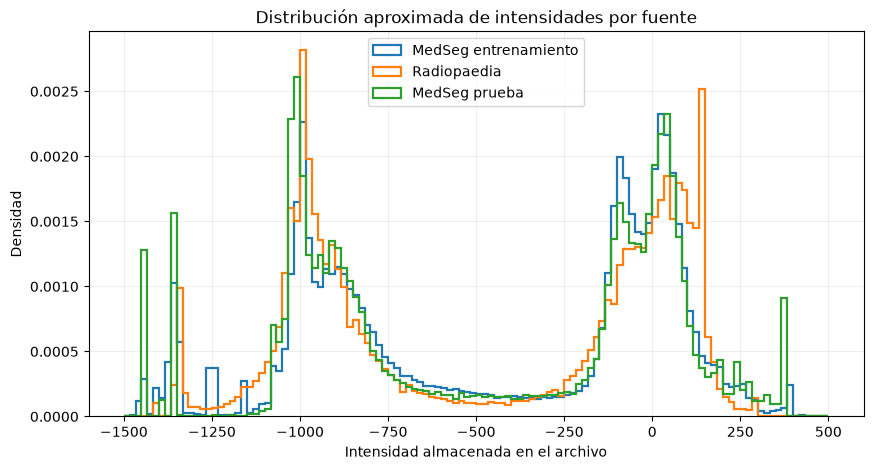

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

rng = np.random.default_rng(SEED)
for name, values in pixel_samples.items():
    if len(values) > 400_000:
        values = rng.choice(values, size=400_000, replace=False)
    ax.hist(
        values,
        bins=120,
        range=(-1500, 500),
        density=True,
        histtype="step",
        linewidth=1.6,
        label=name,
    )

ax.set(
    title="Distribución aproximada de intensidades por fuente",
    xlabel="Intensidad almacenada en el archivo",
    ylabel="Densidad",
)
ax.grid(alpha=0.2)
ax.legend()
plt.show()

Las distribuciones generales son parecidas, pero sus colas y medianas no son idénticas. Las imágenes de prueba se acercan más a MedSeg, lo cual es coherente con su procedencia. Esta observación respalda una validación principal construida con MedSeg y el uso de Radiopaedia como información adicional de entrenamiento.

Para el modelado recortaremos las intensidades al intervalo de -1500 a 500 y calcularemos la media y la desviación exclusivamente con los datos de entrenamiento. Las mismas estadísticas se aplicarán después a validación y prueba. De esta forma evitamos que la normalización utilice información reservada para evaluar el modelo.

## Cobertura de las lesiones por corte

Además del porcentaje global, necesitamos conocer cuánto ocupa cada lesión en cada imagen. Esta distribución permite distinguir cortes negativos, lesiones pequeñas y casos extensos. También será útil para construir una división de validación que no concentre accidentalmente todos los casos difíciles en un solo grupo.

In [8]:
def lesion_coverage(mask_array, source, chunk_size=32):
    records = []
    for start in range(0, len(mask_array), chunk_size):
        target = np.asarray(mask_array[start : start + chunk_size, ..., :2])
        coverage = 100 * target.mean(axis=(1, 2))
        for offset, (ground_glass, consolidation) in enumerate(coverage):
            records.append(
                {
                    "fuente": source,
                    "índice": start + offset,
                    "vidrio_esmerilado_pct": ground_glass,
                    "consolidación_pct": consolidation,
                    "lesión_total_pct": ground_glass + consolidation,
                }
            )
    return pd.DataFrame(records)


coverage = pd.concat(
    [
        lesion_coverage(arrays["masks_medseg"], "MedSeg"),
        lesion_coverage(arrays["masks_radiopedia"], "Radiopaedia"),
    ],
    ignore_index=True,
)

coverage.groupby("fuente")[[
    "vidrio_esmerilado_pct",
    "consolidación_pct",
    "lesión_total_pct",
]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(3)

vidrio_esmerilado_pct                                          \
                            count   mean    std  min    25%    50%    75%   
fuente                                                                      
MedSeg                      100.0  4.564  4.848  0.0  1.483  2.719  5.648   
Radiopaedia                 829.0  1.021  2.726  0.0  0.000  0.000  0.290   

                                     ... lesión_total_pct                     \
                90%     95%     max  ...            count   mean    std  min   
fuente                               ...                                       
MedSeg       10.520  15.638  23.528  ...            100.0  6.812  6.083  0.0   
Radiopaedia   3.001   7.360  14.166  ...            829.0  1.249  2.749  0.0   

                                                          
               25%    50%    75%     90%     95%     max  
fuente                                                    
MedSeg       2.463  4.726  9.419  15.908  19.246  25.904  
Radiopaedia  0.000  0.000  1.262   3.263   7.752  14.166  

[2 rows x 30 columns]

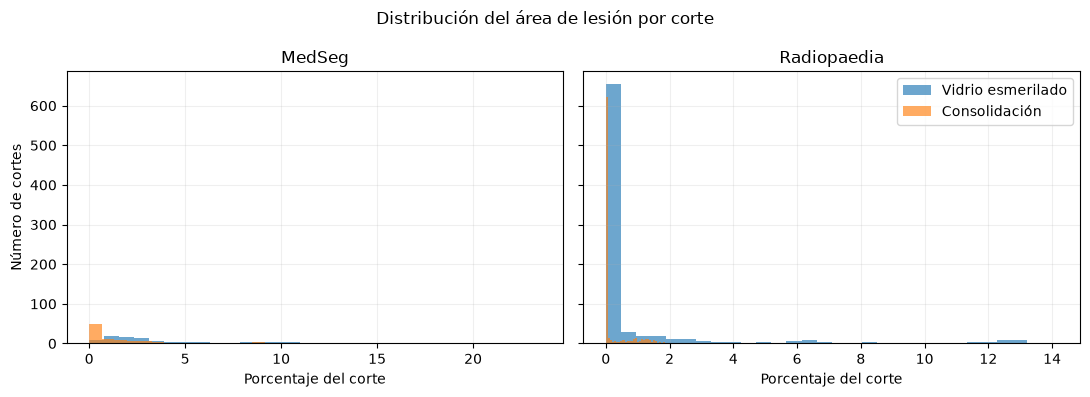

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, source in zip(axes, ["MedSeg", "Radiopaedia"]):
    subset = coverage[coverage["fuente"] == source]
    ax.hist(
        subset["vidrio_esmerilado_pct"],
        bins=30,
        alpha=0.65,
        label="Vidrio esmerilado",
    )
    ax.hist(
        subset["consolidación_pct"],
        bins=30,
        alpha=0.65,
        label="Consolidación",
    )
    ax.set_title(source)
    ax.set_xlabel("Porcentaje del corte")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Número de cortes")
axes[1].legend()
fig.suptitle("Distribución del área de lesión por corte")
fig.tight_layout()
plt.show()

## Exploración visual

Las máscaras aisladas sólo muestran ceros y unos, por lo que resulta más informativo superponerlas sobre la tomografía. Seleccionamos ejemplos de forma reproducible a partir del área de lesión: un caso pequeño, uno cercano a la mediana y los casos con mayor presencia de cada target. La imagen se presenta con una ventana fija para que el contraste sea comparable entre cortes.

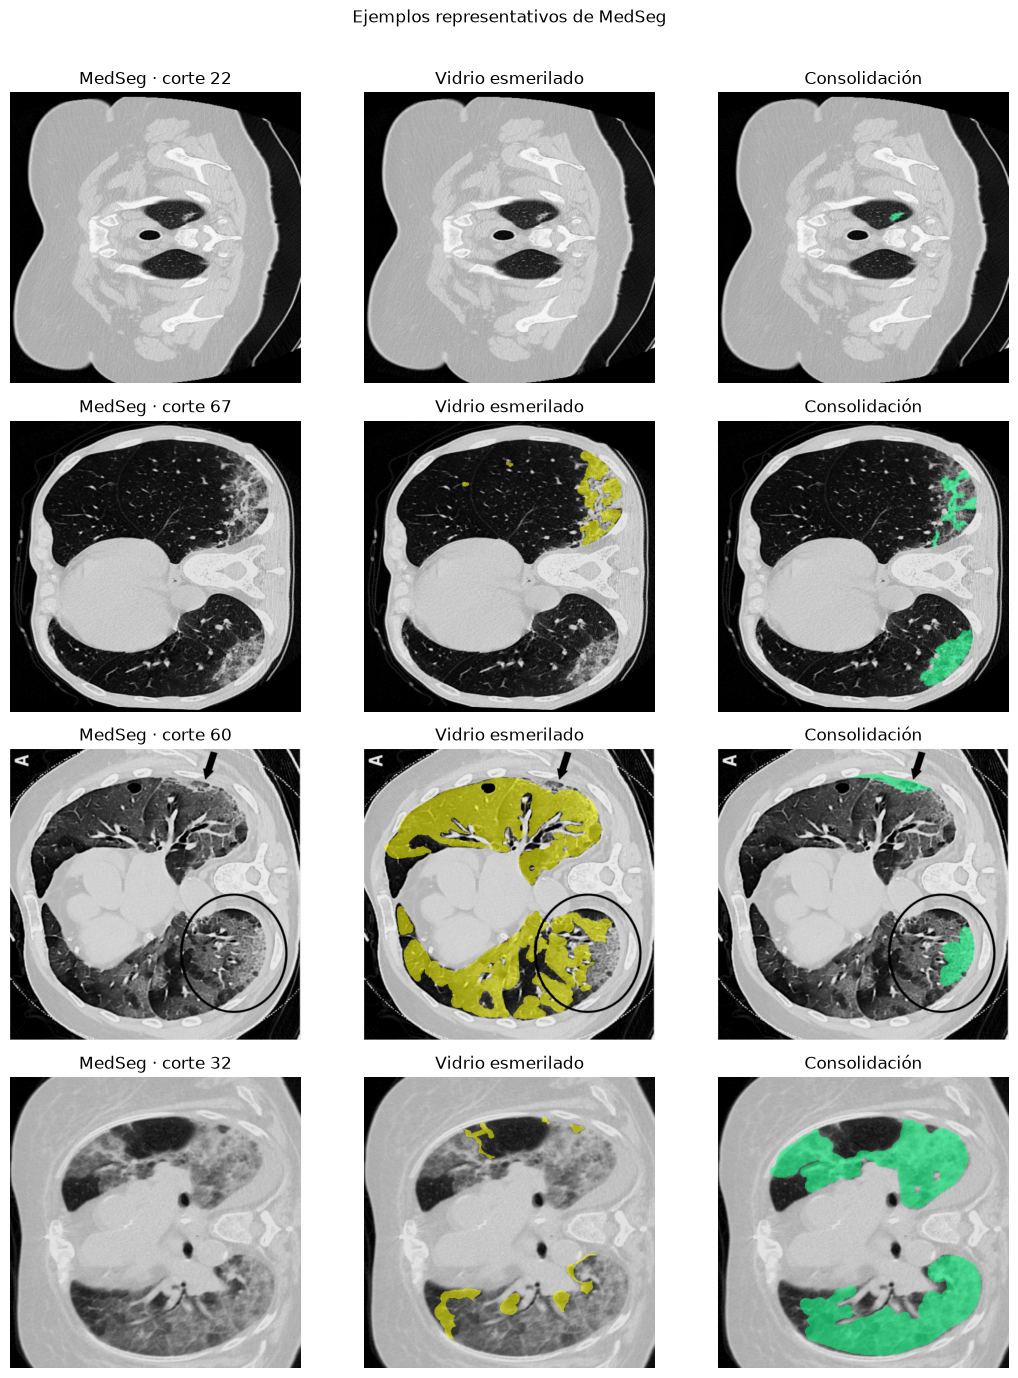

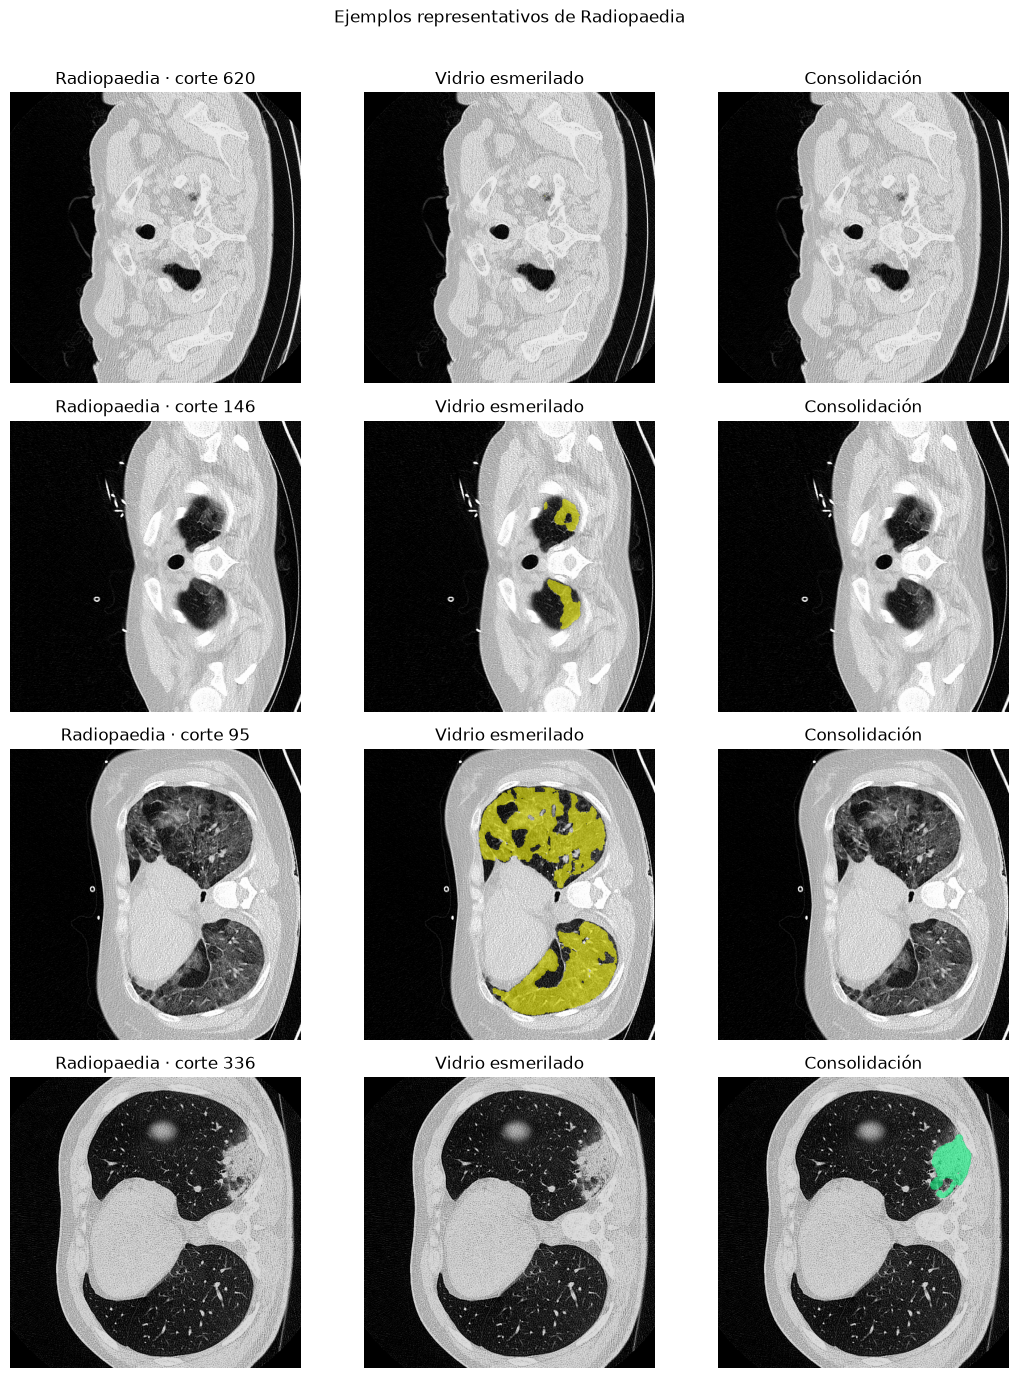

In [10]:
def representative_indices(source_coverage):
    positive = source_coverage[source_coverage["lesión_total_pct"] > 0]
    median_area = positive["lesión_total_pct"].median()
    median_index = (
        positive["lesión_total_pct"] - median_area
    ).abs().idxmin()

    return list(
        dict.fromkeys(
            [
                int(positive.nsmallest(1, "lesión_total_pct")["índice"].iloc[0]),
                int(positive.loc[median_index, "índice"]),
                int(positive.nlargest(1, "vidrio_esmerilado_pct")["índice"].iloc[0]),
                int(positive.nlargest(1, "consolidación_pct")["índice"].iloc[0]),
            ]
        )
    )


def plot_examples(images, masks, indices, source):
    fig, axes = plt.subplots(len(indices), 3, figsize=(11, 3.4 * len(indices)))
    if len(indices) == 1:
        axes = axes[None, :]

    for row, index in enumerate(indices):
        image = np.asarray(images[index, ..., 0])
        ground_glass = np.asarray(masks[index, ..., 0])
        consolidation = np.asarray(masks[index, ..., 1])

        axes[row, 0].imshow(image, cmap="gray", vmin=-1000, vmax=300)
        axes[row, 0].set_title(f"{source} · corte {index}")

        axes[row, 1].imshow(image, cmap="gray", vmin=-1000, vmax=300)
        axes[row, 1].imshow(
            np.ma.masked_where(~ground_glass, ground_glass),
            cmap="autumn",
            alpha=0.55,
            vmin=0,
            vmax=1,
        )
        axes[row, 1].set_title("Vidrio esmerilado")

        axes[row, 2].imshow(image, cmap="gray", vmin=-1000, vmax=300)
        axes[row, 2].imshow(
            np.ma.masked_where(~consolidation, consolidation),
            cmap="winter",
            alpha=0.55,
            vmin=0,
            vmax=1,
        )
        axes[row, 2].set_title("Consolidación")

        for ax in axes[row]:
            ax.axis("off")

    fig.suptitle(f"Ejemplos representativos de {source}", y=1.01)
    fig.tight_layout()
    plt.show()


medseg_indices = representative_indices(
    coverage[coverage["fuente"] == "MedSeg"]
)
radiopaedia_indices = representative_indices(
    coverage[coverage["fuente"] == "Radiopaedia"]
)

plot_examples(
    arrays["images_medseg"],
    arrays["masks_medseg"],
    medseg_indices,
    "MedSeg",
)
plot_examples(
    arrays["images_radiopedia"],
    arrays["masks_radiopedia"],
    radiopaedia_indices,
    "Radiopaedia",
)

## Decisiones derivadas del análisis

El análisis confirma que el principal reto no es reconocer el fondo, sino aprender regiones pequeñas y variables. La consolidación es especialmente escasa en Radiopaedia. Por ello la exactitud global no será nuestra métrica principal: un modelo podría obtener una cifra elevada prediciendo fondo en casi todos los píxeles. Reportaremos Dice o F1 e IoU para cada target y un promedio de ambos.

La validación se construirá con imágenes de MedSeg porque el conjunto de prueba procede de esa fuente. Radiopaedia se utilizará como apoyo durante el entrenamiento, con un muestreo que limite el predominio de sus cortes negativos. Debido a que los archivos no incluyen identificadores de paciente para MedSeg, no es posible garantizar una separación por paciente; esta limitación se mantendrá explícita en la interpretación de resultados.

Trabajaremos inicialmente con imágenes de 256 por 256 píxeles para reducir el costo computacional. Las imágenes se redimensionarán con interpolación bilineal y las máscaras con vecino más cercano. El modelo producirá dos mapas de logits que se convertirán en probabilidades mediante sigmoid. Estudiaremos por separado el efecto de la pérdida Dice y de incorporar Radiopaedia con muestreo balanceado.

## Modelo base y experimentos siguientes

La siguiente etapa reproduce una U-Net convencional inspirada en el notebook de referencia. Nuestro experimento B0 conserva una configuración deliberadamente sencilla: utiliza únicamente MedSeg, no aplica aumentos, se optimiza con Adam y emplea entropía cruzada binaria. A diferencia del notebook original, la implementación fija todas las semillas, calcula la normalización sólo con entrenamiento y produce directamente los dos canales evaluados por Kaggle.

Este modelo no pretende ser la solución final. Su función es establecer una referencia reproducible frente a la cual podamos medir la incorporación balanceada de Radiopaedia, la pérdida Dice, los aumentos y otras modificaciones. Cada experimento conservará la misma partición de validación y reportará métricas por clase, tiempo de entrenamiento y ejemplos cualitativos. El modelo final se elegirá con la validación local, no mediante intentos repetidos sobre el leaderboard.

## Experimento B0: partición reproducible

Para conservar una comparación cercana con el trabajo de referencia se reserva el diez por ciento de MedSeg para validación. La selección se realiza con una permutación aleatoria controlada por la semilla global. Una validación de sólo diez imágenes tiene una varianza considerable y no permite garantizar independencia entre pacientes, porque el archivo no contiene identificadores. Estas limitaciones se tendrán presentes al interpretar los resultados y motivarán una estrategia más robusta en los experimentos posteriores.

In [11]:
medseg_size = len(arrays["images_medseg"])
rng_split = np.random.default_rng(SEED)
shuffled_indices = rng_split.permutation(medseg_size)

validation_size = max(1, int(round(0.10 * medseg_size)))
val_indices_b0 = np.sort(shuffled_indices[:validation_size])
train_indices_b0 = np.sort(shuffled_indices[validation_size:])

split_membership = pd.DataFrame(
    {
        "índice": np.concatenate([train_indices_b0, val_indices_b0]),
        "partición": ["Entrenamiento"] * len(train_indices_b0)
        + ["Validación"] * len(val_indices_b0),
    }
)
split_audit = (
    split_membership.merge(
        coverage[coverage["fuente"] == "MedSeg"],
        on="índice",
        how="left",
    )
    .groupby("partición")
    .agg(
        cortes=("índice", "size"),
        cortes_con_lesión=("lesión_total_pct", lambda x: int((x > 0).sum())),
        lesión_media_pct=("lesión_total_pct", "mean"),
        lesión_mediana_pct=("lesión_total_pct", "median"),
        vidrio_medio_pct=("vidrio_esmerilado_pct", "mean"),
        consolidación_media_pct=("consolidación_pct", "mean"),
    )
)

print(f"Índices de validación B0: {val_indices_b0.tolist()}")
split_audit.style.format(precision=3)

Índices de validación B0: [18, 21, 27, 33, 42, 50, 56, 59, 71, 92]


,cortes,cortes_con_lesión,lesión_media_pct,lesión_mediana_pct,vidrio_medio_pct,consolidación_media_pct
partición,,,,,,
Entrenamiento,90,89,6.979,4.839,4.537,2.442
Validación,10,10,5.308,3.295,4.806,0.503


## Preparación de las entradas con PyTorch

A partir de esta sección toda la implementación utiliza PyTorch. Las estadísticas de normalización se calculan exclusivamente con MedSeg de entrenamiento. Primero limitamos las intensidades al intervalo de -1500 a 500 y después usamos la región situada entre los percentiles 5 y 95 para estimar una media y una desviación resistentes a valores extremos.

Las imágenes se reducen a 256 por 256 mediante interpolación bilineal. Las máscaras se redimensionan con vecino más cercano porque contienen categorías y no intensidades continuas. El `Dataset` devuelve tensores con el orden de PyTorch: canales, alto y ancho.

In [12]:
import copy
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
TARGET_SIZE = 256
BATCH_SIZE = 4
MAX_EPOCHS = 25
STEPS_PER_EPOCH = int(np.ceil(len(train_indices_b0) / BATCH_SIZE))
MAX_OPTIMIZER_STEPS = MAX_EPOCHS * STEPS_PER_EPOCH

print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo: {DEVICE}")
print(f"Precisión mixta: {USE_AMP}")
print(
    f"Presupuesto por experimento: {MAX_EPOCHS} épocas, "
    f"{STEPS_PER_EPOCH} lotes por época y "
    f"{MAX_OPTIMIZER_STEPS} actualizaciones como máximo."
)
if DEVICE.type == "cpu":
    print("Para entrenar los tres experimentos conviene activar una GPU en Kaggle.")

PyTorch: 2.14.0
Dispositivo: cpu
Precisión mixta: False
Presupuesto por experimento: 25 épocas, 23 lotes por época y 575 actualizaciones como máximo.
Para entrenar los tres experimentos conviene activar una GPU en Kaggle.


In [13]:
def estimate_train_stats(image_array, indices, stride=8):
    sample = np.stack(
        [
            np.asarray(
                image_array[index, ::stride, ::stride, 0],
                dtype=np.float32,
            )
            for index in indices
        ]
    )
    sample = np.clip(sample, -1500.0, 500.0)
    percentile_5, percentile_95 = np.percentile(sample, [5, 95])
    central = sample[
        (sample > percentile_5) & (sample < percentile_95)
    ]
    mean = float(central.mean())
    std = float(central.std())

    if std < 1e-8:
        raise ValueError("La desviación estándar es demasiado pequeña.")

    return mean, std, float(percentile_5), float(percentile_95)


train_mean, train_std, train_p5, train_p95 = estimate_train_stats(
    arrays["images_medseg"], train_indices_b0
)

pd.Series(
    {
        "media_entrenamiento": train_mean,
        "desviación_entrenamiento": train_std,
        "percentil_5": train_p5,
        "percentil_95": train_p95,
    },
    name="MedSeg entrenamiento",
).to_frame().style.format(precision=3)

,MedSeg entrenamiento
media_entrenamiento,-422.559
desviación_entrenamiento,440.768
percentil_5,-1252.000
percentil_95,147.183


In [14]:
def prepare_case(source_key, index, mean, std, target_size=256):
    image = np.asarray(
        arrays[f"images_{source_key}"][index], dtype=np.float32
    ).copy()
    targets = np.asarray(
        arrays[f"masks_{source_key}"][index, ..., :2],
        dtype=np.float32,
    )

    image = np.clip(image, -1500.0, 500.0)
    image = (image - mean) / std

    image_tensor = torch.from_numpy(image).permute(2, 0, 1)
    target_tensor = torch.from_numpy(targets).permute(2, 0, 1)

    image_tensor = F.interpolate(
        image_tensor.unsqueeze(0),
        size=(target_size, target_size),
        mode="bilinear",
        align_corners=False,
        antialias=True,
    ).squeeze(0)
    target_tensor = F.interpolate(
        target_tensor.unsqueeze(0),
        size=(target_size, target_size),
        mode="nearest",
    ).squeeze(0)

    return image_tensor.float(), target_tensor.float()


def horizontal_flip(image_tensor, target_tensor):
    return torch.flip(image_tensor, dims=(-1,)), torch.flip(
        target_tensor, dims=(-1,)
    )


class CTMaskDataset(Dataset):
    def __init__(
        self,
        source_key,
        indices,
        mean,
        std,
        target_size=256,
        augment=False,
        seed=42,
    ):
        self.source_key = source_key
        self.indices = np.asarray(indices, dtype=int)
        self.mean = mean
        self.std = std
        self.target_size = target_size
        self.augment = augment
        self.seed = seed
        self.epoch = 0

    def __len__(self):
        return len(self.indices)

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __getitem__(self, position):
        image_tensor, target_tensor = prepare_case(
            self.source_key,
            int(self.indices[position]),
            self.mean,
            self.std,
            self.target_size,
        )
        if self.augment:
            rng = np.random.default_rng(
                self.seed + self.epoch * len(self) + position
            )
            if rng.random() < 0.5:
                image_tensor, target_tensor = horizontal_flip(
                    image_tensor, target_tensor
                )
        return image_tensor, target_tensor


train_dataset = CTMaskDataset(
    "medseg", train_indices_b0, train_mean, train_std, TARGET_SIZE
)
validation_dataset = CTMaskDataset(
    "medseg", val_indices_b0, train_mean, train_std, TARGET_SIZE
)


def make_medseg_loaders(seed):
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=USE_AMP,
    )
    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=USE_AMP,
    )
    return train_loader, validation_loader


sample_image, sample_mask = train_dataset[0]
print("Imagen:", tuple(sample_image.shape), sample_image.dtype)
print("Máscara:", tuple(sample_mask.shape), sample_mask.dtype)
print("Valores de la máscara:", torch.unique(sample_mask).tolist())

Imagen: (1, 256, 256) torch.float32
Máscara: (2, 256, 256) torch.float32
Valores de la máscara: [0.0, 1.0]


El mapeo de memoria se conserva: cada llamada al `Dataset` abre sólo el corte solicitado, lo transforma a `float32` y lo redimensiona. `DataLoader` forma lotes de cuatro ejemplos. Dejamos `num_workers=0` para que el mismo notebook funcione tanto en Windows como en Kaggle sin duplicar los arreglos mapeados en procesos secundarios.

## Arquitectura U-Net en PyTorch

La red tiene un encoder que aprende características a escalas cada vez menores y un decoder que recupera la resolución espacial. Las conexiones directas unen características del encoder con el nivel correspondiente del decoder; de este modo la red combina contexto con información precisa de los bordes.

La última convolución produce dos mapas de logits, uno por target. No aplicamos sigmoid dentro de `forward`, porque `BCEWithLogitsLoss` combina sigmoid y entropía cruzada de forma numéricamente estable. Sigmoid se aplica después para calcular métricas y construir las máscaras.

In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, inputs):
        return self.block(inputs)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=2):
        super().__init__()
        self.encoder_1 = DoubleConv(in_channels, 32)
        self.encoder_2 = DoubleConv(32, 64)
        self.encoder_3 = DoubleConv(64, 128)
        self.encoder_4 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up_4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.decoder_4 = DoubleConv(512, 256)
        self.up_3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.decoder_3 = DoubleConv(256, 128)
        self.up_2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.decoder_2 = DoubleConv(128, 64)
        self.up_1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.decoder_1 = DoubleConv(64, 32)

        self.output = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, inputs):
        skip_1 = self.encoder_1(inputs)
        skip_2 = self.encoder_2(self.pool(skip_1))
        skip_3 = self.encoder_3(self.pool(skip_2))
        skip_4 = self.encoder_4(self.pool(skip_3))

        center = self.bottleneck(self.pool(skip_4))

        decoded_4 = self.up_4(center)
        decoded_4 = self.decoder_4(torch.cat([decoded_4, skip_4], dim=1))
        decoded_3 = self.up_3(decoded_4)
        decoded_3 = self.decoder_3(torch.cat([decoded_3, skip_3], dim=1))
        decoded_2 = self.up_2(decoded_3)
        decoded_2 = self.decoder_2(torch.cat([decoded_2, skip_2], dim=1))
        decoded_1 = self.up_1(decoded_2)
        decoded_1 = self.decoder_1(torch.cat([decoded_1, skip_1], dim=1))

        return self.output(decoded_1)


torch.manual_seed(SEED)
architecture_check = UNet()
total_parameters = sum(
    parameter.numel() for parameter in architecture_check.parameters()
)
trainable_parameters = sum(
    parameter.numel()
    for parameter in architecture_check.parameters()
    if parameter.requires_grad
)

with torch.no_grad():
    output_check = architecture_check(sample_image.unsqueeze(0))

print(architecture_check)
print(f"Parámetros totales: {total_parameters:,}")
print(f"Parámetros entrenables: {trainable_parameters:,}")
print("Forma de salida:", tuple(output_check.shape))
del architecture_check, output_check

UNet(
  (encoder_1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (encoder_2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=Tru

## Pérdidas, métricas y ciclo de entrenamiento

La competencia utiliza F1 a nivel de píxel. En segmentación binaria este valor coincide con Dice. También reportamos IoU, precisión y sensibilidad, porque dos modelos con Dice parecido pueden cometer errores distintos: uno puede marcar tejido sano como lesión y otro puede omitir lesiones verdaderas.

Adam utiliza una tasa inicial de aprendizaje de 0.001. Entrenamos como máximo 25 épocas, reducimos la tasa cuando la pérdida de validación se estanca y detenemos el proceso después de seis épocas sin mejora en Dice. En GPU activamos precisión mixta para reducir memoria y acelerar las operaciones compatibles.

In [16]:
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probabilities = torch.sigmoid(logits)
        dimensions = (0, 2, 3)
        intersection = (probabilities * targets).sum(dim=dimensions)
        denominator = probabilities.sum(dim=dimensions) + targets.sum(
            dim=dimensions
        )
        dice = (2.0 * intersection + self.smooth) / (
            denominator + self.smooth
        )
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = SoftDiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)


def dice_from_counts(true_positive, false_positive, false_negative):
    denominator = 2 * true_positive + false_positive + false_negative
    return np.divide(
        2 * true_positive,
        denominator,
        out=np.ones_like(true_positive, dtype=float),
        where=denominator != 0,
    )


def run_epoch(model, data_loader, loss_function, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_examples = 0
    true_positive = np.zeros(2, dtype=np.int64)
    false_positive = np.zeros(2, dtype=np.int64)
    false_negative = np.zeros(2, dtype=np.int64)

    for images, targets in data_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits = model(images)
                loss = loss_function(logits, targets)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        batch_size = images.shape[0]
        total_loss += float(loss.detach().cpu()) * batch_size
        total_examples += batch_size

        predictions = torch.sigmoid(logits.detach()) >= 0.5
        truth = targets >= 0.5
        dimensions = (0, 2, 3)
        true_positive += (
            (predictions & truth).sum(dim=dimensions).cpu().numpy()
        )
        false_positive += (
            (predictions & ~truth).sum(dim=dimensions).cpu().numpy()
        )
        false_negative += (
            (~predictions & truth).sum(dim=dimensions).cpu().numpy()
        )

    class_dice = dice_from_counts(
        true_positive, false_positive, false_negative
    )
    return {
        "loss": total_loss / total_examples,
        "dice_vidrio": float(class_dice[0]),
        "dice_consolidación": float(class_dice[1]),
        "dice_promedio": float(class_dice.mean()),
    }

In [17]:
ARTIFACT_DIR = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path("artifacts")
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def train_model(
    model,
    train_loader,
    validation_loader,
    loss_function,
    checkpoint_path,
    max_epochs=25,
    learning_rate=1e-3,
    patience=None,
):
    model = model.to(DEVICE)
    loss_function = loss_function.to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=learning_rate
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best_score = -np.inf
    best_state = None
    epochs_without_improvement = 0
    history = []
    start_time = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        if hasattr(train_loader.dataset, "set_epoch"):
            train_loader.dataset.set_epoch(epoch - 1)

        train_result = run_epoch(
            model,
            train_loader,
            loss_function,
            optimizer=optimizer,
            scaler=scaler,
        )
        with torch.no_grad():
            validation_result = run_epoch(
                model,
                validation_loader,
                loss_function,
            )

        scheduler.step(validation_result["loss"])
        learning_rate_now = optimizer.param_groups[0]["lr"]
        history.append(
            {
                "época": epoch,
                "actualizaciones": epoch * len(train_loader),
                "loss": train_result["loss"],
                "val_loss": validation_result["loss"],
                "dice_promedio": train_result["dice_promedio"],
                "val_dice_promedio": validation_result[
                    "dice_promedio"
                ],
                "val_dice_vidrio": validation_result["dice_vidrio"],
                "val_dice_consolidación": validation_result[
                    "dice_consolidación"
                ],
                "learning_rate": learning_rate_now,
            }
        )

        print(
            f"Época {epoch:02d} | "
            f"loss {train_result['loss']:.4f} | "
            f"val_loss {validation_result['loss']:.4f} | "
            f"val_Dice {validation_result['dice_promedio']:.4f}"
        )

        score = validation_result["dice_promedio"]
        if score > best_score + 1e-6:
            best_score = score
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }
            torch.save(best_state, checkpoint_path)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            patience is not None
            and epochs_without_improvement >= patience
        ):
            print("Early stopping: no mejoró Dice de validación.")
            break

    elapsed_seconds = time.perf_counter() - start_time
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), elapsed_seconds


def predict_probabilities(model, data_loader):
    model.eval()
    predictions = []

    with torch.inference_mode():
        for batch in data_loader:
            images = batch[0].to(DEVICE, non_blocking=True)
            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions.append(
                probabilities.permute(0, 2, 3, 1).cpu().numpy()
            )

    return np.concatenate(predictions, axis=0)


def validation_targets(data_loader):
    targets = []
    for _, batch_targets in data_loader:
        targets.append(batch_targets.permute(0, 2, 3, 1).numpy())
    return np.concatenate(targets, axis=0)

In [18]:
def evaluate_segmentation(y_true, probabilities, thresholds=(0.5, 0.5)):
    records = []

    for channel, (class_name, threshold) in enumerate(
        zip(CLASS_NAMES[:2], thresholds)
    ):
        truth = y_true[..., channel].astype(bool)
        prediction = probabilities[..., channel] >= threshold

        true_positive = int(np.logical_and(truth, prediction).sum())
        false_positive = int(np.logical_and(~truth, prediction).sum())
        false_negative = int(np.logical_and(truth, ~prediction).sum())

        dice_denominator = (
            2 * true_positive + false_positive + false_negative
        )
        iou_denominator = true_positive + false_positive + false_negative
        precision_denominator = true_positive + false_positive
        recall_denominator = true_positive + false_negative

        records.append(
            {
                "clase": class_name,
                "umbral": float(threshold),
                "Dice_F1": (
                    2 * true_positive / dice_denominator
                    if dice_denominator
                    else 1.0
                ),
                "IoU": (
                    true_positive / iou_denominator
                    if iou_denominator
                    else 1.0
                ),
                "precisión": (
                    true_positive / precision_denominator
                    if precision_denominator
                    else 0.0
                ),
                "sensibilidad": (
                    true_positive / recall_denominator
                    if recall_denominator
                    else 0.0
                ),
                "TP": true_positive,
                "FP": false_positive,
                "FN": false_negative,
            }
        )

    result = pd.DataFrame(records)
    average = {
        "clase": "Promedio de targets",
        "umbral": np.nan,
        "Dice_F1": result["Dice_F1"].mean(),
        "IoU": result["IoU"].mean(),
        "precisión": result["precisión"].mean(),
        "sensibilidad": result["sensibilidad"].mean(),
        "TP": result["TP"].sum(),
        "FP": result["FP"].sum(),
        "FN": result["FN"].sum(),
    }
    return pd.concat([result, pd.DataFrame([average])], ignore_index=True)


def pooled_f1(metric_frame):
    # F1 calculado al acumular los píxeles de ambos targets.
    class_rows = metric_frame[
        metric_frame["clase"].isin(CLASS_NAMES[:2])
    ]
    true_positive = int(class_rows["TP"].sum())
    false_positive = int(class_rows["FP"].sum())
    false_negative = int(class_rows["FN"].sum())
    denominator = 2 * true_positive + false_positive + false_negative
    return 2 * true_positive / denominator if denominator else 1.0


def display_metrics(metric_frame):
    return metric_frame.style.format(
        {
            "umbral": "{:.2f}",
            "Dice_F1": "{:.4f}",
            "IoU": "{:.4f}",
            "precisión": "{:.4f}",
            "sensibilidad": "{:.4f}",
            "TP": "{:,}",
            "FP": "{:,}",
            "FN": "{:,}",
        },
        na_rep="—",
    )


def plot_training(history, experiment_name):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["época"], history["loss"], label="Entrenamiento")
    axes[0].plot(history["época"], history["val_loss"], label="Validación")
    axes[0].set(
        title=f"Pérdida de {experiment_name}",
        xlabel="Época",
        ylabel="Pérdida",
    )
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].plot(
        history["época"],
        history["dice_promedio"],
        label="Entrenamiento",
    )
    axes[1].plot(
        history["época"],
        history["val_dice_promedio"],
        label="Validación",
    )
    axes[1].set(
        title=f"Dice de {experiment_name}",
        xlabel="Época",
        ylabel="Dice promedio",
        ylim=(0, 1),
    )
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## Experimento B0: U-Net con BCE

B0 utiliza únicamente las 90 imágenes de MedSeg destinadas a entrenamiento. La función `BCEWithLogitsLoss` trata cada píxel y cada target como una decisión binaria. Este experimento establece la referencia mínima sobre la que mediremos los cambios posteriores.

El notebook original de vimpsykal también parte de una U-Net, pero fue escrito con TensorFlow y reporta cuatro canales de salida. Nuestro B0 es una reproducción adaptada a PyTorch y a los dos targets oficiales. Por eso funciona como línea base medible dentro de nuestra propia partición; no presentamos sus cifras como si fueran una comparación directa con las del autor.

In [19]:
train_loader_b0, validation_loader = make_medseg_loaders(SEED)
y_val = validation_targets(validation_loader)

torch.manual_seed(SEED)
model_b0 = UNet()
model_b0, history_b0, elapsed_b0 = train_model(
    model_b0,
    train_loader_b0,
    validation_loader,
    nn.BCEWithLogitsLoss(),
    ARTIFACT_DIR / "b0_unet_pytorch.pt",
    max_epochs=MAX_EPOCHS,
)

probabilities_val_b0 = predict_probabilities(
    model_b0, validation_loader
)
metrics_b0 = evaluate_segmentation(
    y_val, probabilities_val_b0, thresholds=(0.5, 0.5)
)

print(f"Tiempo B0: {elapsed_b0 / 60:.2f} minutos")
display_metrics(metrics_b0)

Época 01 | loss 0.6579 | val_loss 0.5876 | val_Dice 0.1413
Época 02 | loss 0.4975 | val_loss 0.4399 | val_Dice 0.1703
Época 03 | loss 0.4135 | val_loss 0.3824 | val_Dice 0.2509
Época 04 | loss 0.3419 | val_loss 0.3413 | val_Dice 0.3403
Época 05 | loss 0.2876 | val_loss 0.2569 | val_Dice 0.2342
Época 06 | loss 0.2434 | val_loss 0.2239 | val_Dice 0.2755
Época 07 | loss 0.2126 | val_loss 0.1715 | val_Dice 0.3232
Época 08 | loss 0.1847 | val_loss 0.1278 | val_Dice 0.3065
Época 09 | loss 0.1655 | val_loss 0.1699 | val_Dice 0.2830
Época 10 | loss 0.1469 | val_loss 0.1170 | val_Dice 0.3681
Época 11 | loss 0.1310 | val_loss 0.1181 | val_Dice 0.2849
Época 12 | loss 0.1262 | val_loss 0.1372 | val_Dice 0.3468
Época 13 | loss 0.1176 | val_loss 0.0834 | val_Dice 0.3017
Época 14 | loss 0.1084 | val_loss 0.0736 | val_Dice 0.2646
Época 15 | loss 0.1059 | val_loss 0.1495 | val_Dice 0.2784
Época 16 | loss 0.0998 | val_loss 0.0690 | val_Dice 0.3323
Época 17 | loss 0.0952 | val_loss 0.0607 | val_Dice 0.34

,clase,umbral,Dice_F1,IoU,precisión,sensibilidad,TP,FP,FN
0,Vidrio esmerilado,0.50,0.7434,0.5915,0.8597,0.6548,"20,628","3,367","10,877"
1,Consolidación,0.50,0.0000,0.0000,0.0000,0.0000,0,0,"3,291"
2,Promedio de targets,—,0.3717,0.2958,0.4298,0.3274,"20,628","3,367","14,168"


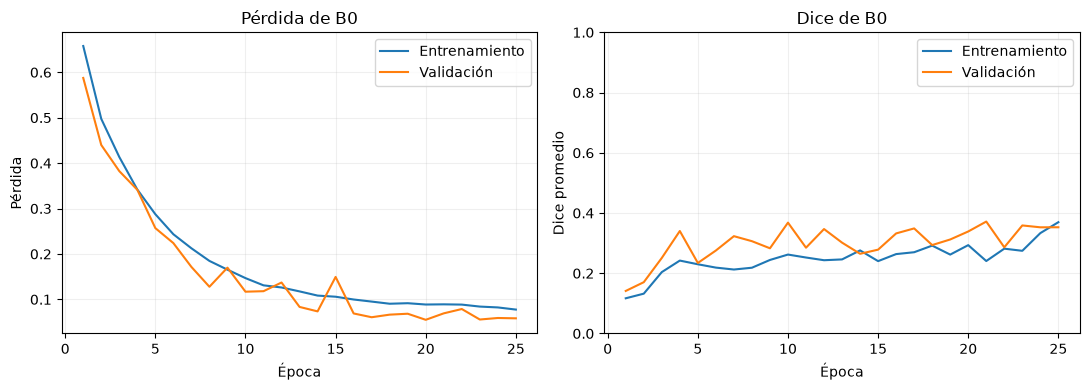

In [20]:
plot_training(history_b0, "B0")

## Experimento E1: BCE más Dice

E1 conserva los datos, la partición, la arquitectura, la inicialización y el optimizador de B0. El único cambio es la pérdida. A la entropía cruzada agregamos Dice suave, que mide el solapamiento usando probabilidades y da más importancia relativa a las regiones pequeñas.

Mantener los demás elementos constantes permite atribuir la diferencia observada principalmente a la función de pérdida.

In [21]:
train_loader_e1, _ = make_medseg_loaders(SEED)

torch.manual_seed(SEED)
model_e1 = UNet()
model_e1, history_e1, elapsed_e1 = train_model(
    model_e1,
    train_loader_e1,
    validation_loader,
    BCEDiceLoss(),
    ARTIFACT_DIR / "e1_unet_bce_dice_pytorch.pt",
    max_epochs=MAX_EPOCHS,
)

probabilities_val_e1 = predict_probabilities(
    model_e1, validation_loader
)
metrics_e1 = evaluate_segmentation(
    y_val, probabilities_val_e1, thresholds=(0.5, 0.5)
)

print(f"Tiempo E1: {elapsed_e1 / 60:.2f} minutos")
display_metrics(metrics_e1)

Época 01 | loss 1.5862 | val_loss 1.4671 | val_Dice 0.2581
Época 02 | loss 1.4184 | val_loss 1.3879 | val_Dice 0.3550
Época 03 | loss 1.3228 | val_loss 1.3059 | val_Dice 0.4280
Época 04 | loss 1.2370 | val_loss 1.2088 | val_Dice 0.4737
Época 05 | loss 1.1612 | val_loss 1.3258 | val_Dice 0.1818
Época 06 | loss 1.1108 | val_loss 1.0736 | val_Dice 0.4112
Época 07 | loss 1.0520 | val_loss 1.0382 | val_Dice 0.4121
Época 08 | loss 0.9767 | val_loss 1.0076 | val_Dice 0.4220
Época 09 | loss 0.9141 | val_loss 0.9143 | val_Dice 0.4453
Época 10 | loss 0.8607 | val_loss 0.8677 | val_Dice 0.4587
Época 11 | loss 0.8115 | val_loss 0.8206 | val_Dice 0.4459
Época 12 | loss 0.7920 | val_loss 0.7772 | val_Dice 0.4970
Época 13 | loss 0.7446 | val_loss 0.7495 | val_Dice 0.4679
Época 14 | loss 0.7219 | val_loss 0.7483 | val_Dice 0.4572
Época 15 | loss 0.7135 | val_loss 0.7418 | val_Dice 0.4432
Época 16 | loss 0.6821 | val_loss 0.6711 | val_Dice 0.5016
Época 17 | loss 0.6621 | val_loss 0.7257 | val_Dice 0.43

,clase,umbral,Dice_F1,IoU,precisión,sensibilidad,TP,FP,FN
0,Vidrio esmerilado,0.50,0.7637,0.6177,0.7886,0.7402,"23,320","6,250","8,185"
1,Consolidación,0.50,0.4522,0.2921,0.3543,0.6247,"2,056","3,747","1,235"
2,Promedio de targets,—,0.6079,0.4549,0.5715,0.6825,"25,376","9,997","9,420"


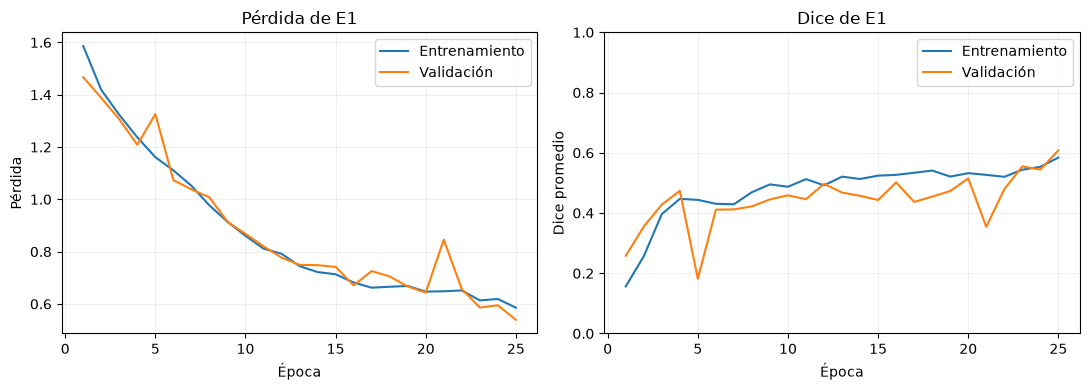

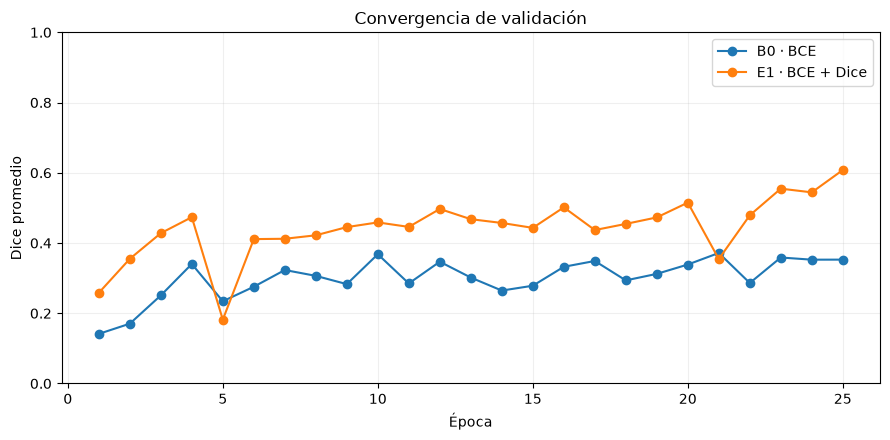

In [22]:
plot_training(history_e1, "E1")

convergence_comparison = pd.concat(
    [
        history_b0.assign(experimento="B0 · BCE"),
        history_e1.assign(experimento="E1 · BCE + Dice"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(9, 4.5))
for experiment_name, experiment_history in convergence_comparison.groupby(
    "experimento"
):
    ax.plot(
        experiment_history["época"],
        experiment_history["val_dice_promedio"],
        marker="o",
        label=experiment_name,
    )
ax.set(
    title="Convergencia de validación",
    xlabel="Época",
    ylabel="Dice promedio",
    ylim=(0, 1),
)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

## Experimento E2: incorporación balanceada de Radiopaedia

Radiopaedia contiene más cortes que MedSeg, pero una proporción menor de lesión. Una concatenación directa haría que esta fuente dominara el entrenamiento. En E2 cada lote contiene dos ejemplos de MedSeg, un corte de Radiopaedia con lesión y uno sin lesión.

El modelo conserva la misma U-Net y utiliza la pérdida que haya obtenido el mayor Dice promedio entre B0 y E1. Así E2 mide principalmente el efecto de ampliar y balancear las fuentes de datos.

In [23]:
def mean_target_dice(metric_frame):
    return float(
        metric_frame.loc[
            metric_frame["clase"] == "Promedio de targets",
            "Dice_F1",
        ].iloc[0]
    )


if mean_target_dice(metrics_e1) >= mean_target_dice(metrics_b0):
    selected_loss_e2 = BCEDiceLoss()
    selected_loss_name_e2 = "BCE + Dice"
    selected_reference_name_e2 = "E1"
else:
    selected_loss_e2 = nn.BCEWithLogitsLoss()
    selected_loss_name_e2 = "BCE"
    selected_reference_name_e2 = "B0"

radiopaedia_coverage = coverage[coverage["fuente"] == "Radiopaedia"]
radiopaedia_positive_indices = radiopaedia_coverage.loc[
    radiopaedia_coverage["lesión_total_pct"] > 0, "índice"
].to_numpy(dtype=int)
radiopaedia_negative_indices = radiopaedia_coverage.loc[
    radiopaedia_coverage["lesión_total_pct"] == 0, "índice"
].to_numpy(dtype=int)

print(
    f"Pérdida seleccionada: {selected_loss_name_e2}. "
    f"Referencia anterior: {selected_reference_name_e2}."
)
pd.DataFrame(
    {
        "grupo": [
            "MedSeg entrenamiento",
            "Radiopaedia con lesión",
            "Radiopaedia sin lesión",
        ],
        "disponibles": [
            len(train_indices_b0),
            len(radiopaedia_positive_indices),
            len(radiopaedia_negative_indices),
        ],
        "por_lote": [2, 1, 1],
    }
)

Pérdida seleccionada: BCE + Dice. Referencia anterior: E1.


,grupo,disponibles,por_lote
0,MedSeg entrenamiento,90,2
1,Radiopaedia con lesión,372,1
2,Radiopaedia sin lesión,457,1


In [24]:
class BalancedSourcesDataset(Dataset):
    def __init__(
        self,
        medseg_indices,
        radiopaedia_positive,
        radiopaedia_negative,
        mean,
        std,
        steps_per_epoch,
        target_size=256,
        seed=42,
        augment=False,
    ):
        self.medseg_indices = np.asarray(medseg_indices, dtype=int)
        self.radiopaedia_positive = np.asarray(
            radiopaedia_positive, dtype=int
        )
        self.radiopaedia_negative = np.asarray(
            radiopaedia_negative, dtype=int
        )
        self.mean = mean
        self.std = std
        self.steps_per_epoch = steps_per_epoch
        self.target_size = target_size
        self.seed = seed
        self.augment = augment
        self.epoch = 0

    def __len__(self):
        return self.steps_per_epoch * 4

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __getitem__(self, position):
        batch_index = position // 4
        slot = position % 4
        rng = np.random.default_rng(
            self.seed + self.epoch * self.steps_per_epoch + batch_index
        )
        plan = [
            ("medseg", int(rng.choice(self.medseg_indices))),
            ("medseg", int(rng.choice(self.medseg_indices))),
            (
                "radiopedia",
                int(rng.choice(self.radiopaedia_positive)),
            ),
            (
                "radiopedia",
                int(rng.choice(self.radiopaedia_negative)),
            ),
        ]
        rng.shuffle(plan)
        source_key, index = plan[slot]
        image_tensor, target_tensor = prepare_case(
            source_key,
            index,
            self.mean,
            self.std,
            self.target_size,
        )
        if self.augment and rng.random() < 0.5:
            image_tensor, target_tensor = horizontal_flip(
                image_tensor, target_tensor
            )
        return image_tensor, target_tensor


e2_steps_per_epoch = STEPS_PER_EPOCH
train_dataset_e2 = BalancedSourcesDataset(
    train_indices_b0,
    radiopaedia_positive_indices,
    radiopaedia_negative_indices,
    train_mean,
    train_std,
    steps_per_epoch=e2_steps_per_epoch,
    target_size=TARGET_SIZE,
    seed=SEED,
)
train_loader_e2 = DataLoader(
    train_dataset_e2,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=USE_AMP,
)

sample_x_e2, sample_y_e2 = next(iter(train_loader_e2))
print("Lotes por época:", len(train_loader_e2))
print("Forma del lote:", tuple(sample_x_e2.shape), tuple(sample_y_e2.shape))

Lotes por época: 23
Forma del lote: (4, 1, 256, 256) (4, 2, 256, 256)


In [25]:
torch.manual_seed(SEED)
model_e2 = UNet()
model_e2, history_e2, elapsed_e2 = train_model(
    model_e2,
    train_loader_e2,
    validation_loader,
    selected_loss_e2,
    ARTIFACT_DIR / "e2_unet_balanced_pytorch.pt",
    max_epochs=MAX_EPOCHS,
)

probabilities_val_e2 = predict_probabilities(
    model_e2, validation_loader
)
metrics_e2 = evaluate_segmentation(
    y_val, probabilities_val_e2, thresholds=(0.5, 0.5)
)

print(f"Tiempo E2: {elapsed_e2 / 60:.2f} minutos")
display_metrics(metrics_e2)

Época 01 | loss 1.5963 | val_loss 1.6516 | val_Dice 0.0894
Época 02 | loss 1.4471 | val_loss 1.3838 | val_Dice 0.3325
Época 03 | loss 1.3469 | val_loss 1.2850 | val_Dice 0.3837
Época 04 | loss 1.2492 | val_loss 1.2353 | val_Dice 0.4124
Época 05 | loss 1.1816 | val_loss 1.2481 | val_Dice 0.2293
Época 06 | loss 1.1085 | val_loss 1.0929 | val_Dice 0.3981
Época 07 | loss 1.0365 | val_loss 1.0643 | val_Dice 0.4529
Época 08 | loss 1.0113 | val_loss 0.9719 | val_Dice 0.3783
Época 09 | loss 0.9551 | val_loss 0.9267 | val_Dice 0.4425
Época 10 | loss 0.8764 | val_loss 0.8446 | val_Dice 0.4748
Época 11 | loss 0.8499 | val_loss 0.8229 | val_Dice 0.4817
Época 12 | loss 0.8165 | val_loss 0.8275 | val_Dice 0.4176
Época 13 | loss 0.7852 | val_loss 0.7713 | val_Dice 0.4557
Época 14 | loss 0.7220 | val_loss 0.6968 | val_Dice 0.5086
Época 15 | loss 0.6981 | val_loss 0.6384 | val_Dice 0.5516
Época 16 | loss 0.6949 | val_loss 0.6363 | val_Dice 0.5485
Época 17 | loss 0.6760 | val_loss 0.6532 | val_Dice 0.53

,clase,umbral,Dice_F1,IoU,precisión,sensibilidad,TP,FP,FN
0,Vidrio esmerilado,0.50,0.7443,0.5928,0.8446,0.6653,"20,961","3,856","10,544"
1,Consolidación,0.50,0.4253,0.2701,0.3715,0.4974,"1,637","2,770","1,654"
2,Promedio de targets,—,0.5848,0.4314,0.6080,0.5814,"22,598","6,626","12,198"


## Experimento E3: aumento horizontal moderado

E3 conserva la arquitectura, la pérdida, las fuentes balanceadas y el mismo número de actualizaciones de E2. El único cambio es que cada imagen de entrenamiento tiene una probabilidad de 50 % de reflejarse horizontalmente junto con su máscara. Este aumento es razonable para cortes axiales porque intercambia izquierda y derecha sin deformar las lesiones.

No aplicamos giros grandes, recortes agresivos ni reflexiones verticales, ya que podrían crear anatomía poco realista. Esta comparación nos permite saber si una variación sencilla ayuda a generalizar con el conjunto disponible.

In [26]:
train_dataset_e3 = BalancedSourcesDataset(
    train_indices_b0,
    radiopaedia_positive_indices,
    radiopaedia_negative_indices,
    train_mean,
    train_std,
    steps_per_epoch=STEPS_PER_EPOCH,
    target_size=TARGET_SIZE,
    seed=SEED,
    augment=True,
)
train_loader_e3 = DataLoader(
    train_dataset_e3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=USE_AMP,
)

torch.manual_seed(SEED)
model_e3 = UNet()
model_e3, history_e3, elapsed_e3 = train_model(
    model_e3,
    train_loader_e3,
    validation_loader,
    selected_loss_e2,
    ARTIFACT_DIR / "e3_unet_horizontal_flip_pytorch.pt",
    max_epochs=MAX_EPOCHS,
)

probabilities_val_e3 = predict_probabilities(
    model_e3, validation_loader
)
metrics_e3 = evaluate_segmentation(
    y_val, probabilities_val_e3, thresholds=(0.5, 0.5)
)

print(f"Tiempo E3: {elapsed_e3 / 60:.2f} minutos")
display_metrics(metrics_e3)

Época 01 | loss 1.5938 | val_loss 2.7625 | val_Dice 0.0904
Época 02 | loss 1.4452 | val_loss 1.3472 | val_Dice 0.3649
Época 03 | loss 1.3472 | val_loss 1.3012 | val_Dice 0.3659
Época 04 | loss 1.2506 | val_loss 1.2231 | val_Dice 0.4024
Época 05 | loss 1.1826 | val_loss 1.1467 | val_Dice 0.3827
Época 06 | loss 1.1125 | val_loss 1.1226 | val_Dice 0.3949
Época 07 | loss 1.0398 | val_loss 1.0361 | val_Dice 0.4451
Época 08 | loss 1.0169 | val_loss 0.9747 | val_Dice 0.3758
Época 09 | loss 0.9761 | val_loss 0.9077 | val_Dice 0.4495
Época 10 | loss 0.8992 | val_loss 0.8891 | val_Dice 0.4501
Época 11 | loss 0.8729 | val_loss 0.8372 | val_Dice 0.4683
Época 12 | loss 0.8487 | val_loss 0.8083 | val_Dice 0.4403
Época 13 | loss 0.8040 | val_loss 0.8373 | val_Dice 0.4276
Época 14 | loss 0.7623 | val_loss 0.7785 | val_Dice 0.4475
Época 15 | loss 0.7080 | val_loss 0.6733 | val_Dice 0.5304
Época 16 | loss 0.7180 | val_loss 0.6730 | val_Dice 0.4987
Época 17 | loss 0.7011 | val_loss 0.6767 | val_Dice 0.51

,clase,umbral,Dice_F1,IoU,precisión,sensibilidad,TP,FP,FN
0,Vidrio esmerilado,0.50,0.7268,0.5709,0.8378,0.6418,"20,219","3,914","11,286"
1,Consolidación,0.50,0.3871,0.2400,0.3528,0.4287,"1,411","2,589","1,880"
2,Promedio de targets,—,0.5569,0.4054,0.5953,0.5353,"21,630","6,503","13,166"


## Comparación de los experimentos

Los cuatro modelos se evalúan sobre exactamente las mismas diez imágenes y todos reciben el mismo presupuesto máximo de actualizaciones. Revisamos cada target por separado, porque una mejora del promedio no sería suficiente si la consolidación empeorara de forma importante.

In [27]:
experiment_metrics = pd.concat(
    [
        metrics_b0.assign(experimento="B0 · BCE"),
        metrics_e1.assign(experimento="E1 · BCE + Dice"),
        metrics_e2.assign(
            experimento=(
                f"E2 · Fuentes balanceadas · {selected_loss_name_e2}"
            )
        ),
        metrics_e3.assign(
            experimento=(
                f"E3 · Balanceado + reflejo · {selected_loss_name_e2}"
            )
        ),
    ],
    ignore_index=True,
)

experiment_summary = pd.DataFrame(
    [
        {
            "experimento": "B0 · BCE",
            "datos": "MedSeg",
            "pérdida": "BCE",
            "épocas": len(history_b0),
            "actualizaciones": len(history_b0) * len(train_loader_b0),
            "minutos": elapsed_b0 / 60,
            "Dice_promedio": mean_target_dice(metrics_b0),
            "F1_acumulado": pooled_f1(metrics_b0),
        },
        {
            "experimento": "E1 · BCE + Dice",
            "datos": "MedSeg",
            "pérdida": "BCE + Dice",
            "épocas": len(history_e1),
            "actualizaciones": len(history_e1) * len(train_loader_e1),
            "minutos": elapsed_e1 / 60,
            "Dice_promedio": mean_target_dice(metrics_e1),
            "F1_acumulado": pooled_f1(metrics_e1),
        },
        {
            "experimento": (
                f"E2 · Fuentes balanceadas · {selected_loss_name_e2}"
            ),
            "datos": "MedSeg + Radiopaedia balanceados",
            "pérdida": selected_loss_name_e2,
            "épocas": len(history_e2),
            "actualizaciones": len(history_e2) * len(train_loader_e2),
            "minutos": elapsed_e2 / 60,
            "Dice_promedio": mean_target_dice(metrics_e2),
            "F1_acumulado": pooled_f1(metrics_e2),
        },
        {
            "experimento": (
                f"E3 · Balanceado + reflejo · {selected_loss_name_e2}"
            ),
            "datos": "MedSeg + Radiopaedia + reflejo horizontal",
            "pérdida": selected_loss_name_e2,
            "épocas": len(history_e3),
            "actualizaciones": len(history_e3) * len(train_loader_e3),
            "minutos": elapsed_e3 / 60,
            "Dice_promedio": mean_target_dice(metrics_e3),
            "F1_acumulado": pooled_f1(metrics_e3),
        },
    ]
)
experiment_summary.style.format(
    {
        "minutos": "{:.2f}",
        "Dice_promedio": "{:.4f}",
        "F1_acumulado": "{:.4f}",
    }
)

,experimento,datos,pérdida,épocas,actualizaciones,minutos,Dice_promedio,F1_acumulado
0,B0 · BCE,MedSeg,BCE,25,575,6.80,0.3717,0.7017
1,E1 · BCE + Dice,MedSeg,BCE + Dice,25,575,7.94,0.6079,0.7233
2,E2 · Fuentes balanceadas · BCE + Dice,MedSeg + Radiopaedia balanceados,BCE + Dice,25,575,8.14,0.5848,0.7060
3,E3 · Balanceado + reflejo · BCE + Dice,MedSeg + Radiopaedia + reflejo horizontal,BCE + Dice,25,575,7.74,0.5569,0.6874


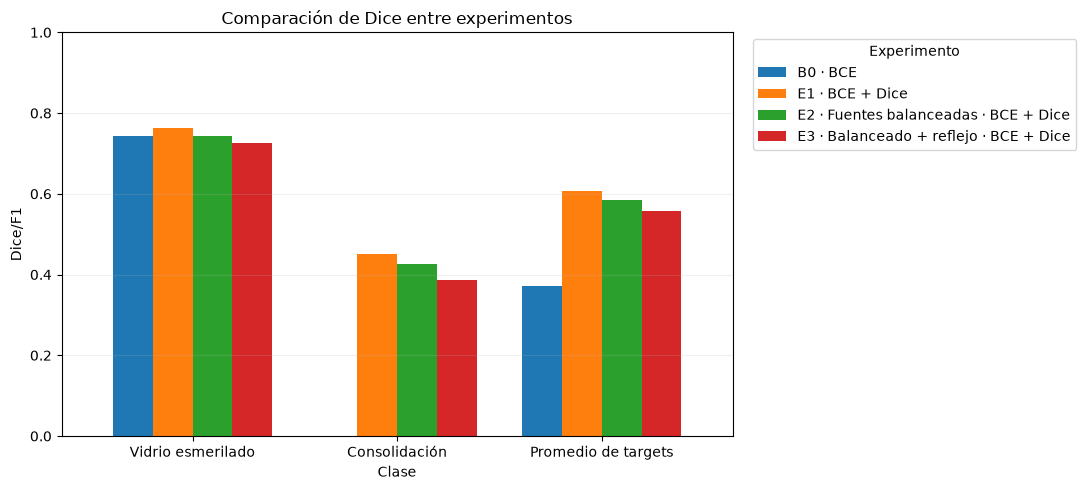

In [28]:
dice_comparison = experiment_metrics.pivot(
    index="clase",
    columns="experimento",
    values="Dice_F1",
).loc[
    ["Vidrio esmerilado", "Consolidación", "Promedio de targets"]
]

ax = dice_comparison.plot(kind="bar", figsize=(11, 5), width=0.78)
ax.set(
    title="Comparación de Dice entre experimentos",
    xlabel="Clase",
    ylabel="Dice/F1",
    ylim=(0, 1),
)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.2)
ax.legend(title="Experimento", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Selección del modelo y ajuste de umbrales

La competencia calcula F1 píxel a píxel sobre los dos targets. Como la entrega aplana ambos canales en una sola columna, usamos como criterio principal el **F1 acumulado**: primero sumamos verdaderos positivos, falsos positivos y falsos negativos de vidrio esmerilado y consolidación, y después calculamos F1. También conservamos Dice por clase y su promedio para que el resultado siga siendo interpretable.

Antes de seleccionar el modelo, las probabilidades regresan de 256 a 512 por 512 mediante interpolación bilineal y se comparan con las máscaras originales. Después probamos conjuntamente 17 valores entre 0.10 y 0.90 para cada target. Esta operación no cambia los pesos de la red; sólo modifica la regla que convierte probabilidades en etiquetas binarias. El conjunto de prueba permanece aislado hasta cerrar el modelo y los umbrales.

In [29]:
def resize_probabilities(probabilities, output_size=512):
    probability_tensor = torch.from_numpy(probabilities).permute(
        0, 3, 1, 2
    )
    return F.interpolate(
        probability_tensor,
        size=(output_size, output_size),
        mode="bilinear",
        align_corners=False,
        antialias=True,
    ).permute(0, 2, 3, 1).numpy()


y_val_native = np.asarray(
    arrays["masks_medseg"][val_indices_b0, ..., :2],
    dtype=np.uint8,
)

experiment_candidates = {
    "B0 · BCE": {
        "model": model_b0,
        "probabilities": probabilities_val_b0,
    },
    "E1 · BCE + Dice": {
        "model": model_e1,
        "probabilities": probabilities_val_e1,
    },
    f"E2 · Fuentes balanceadas · {selected_loss_name_e2}": {
        "model": model_e2,
        "probabilities": probabilities_val_e2,
    },
    f"E3 · Balanceado + reflejo · {selected_loss_name_e2}": {
        "model": model_e3,
        "probabilities": probabilities_val_e3,
    },
}

native_records = []
for experiment_name, candidate in experiment_candidates.items():
    candidate["native_probabilities"] = resize_probabilities(
        candidate["probabilities"], output_size=512
    )
    candidate["native_metrics"] = evaluate_segmentation(
        y_val_native,
        candidate["native_probabilities"],
        thresholds=(0.5, 0.5),
    )
    candidate["pooled_f1"] = pooled_f1(candidate["native_metrics"])
    native_records.append(
        {
            "experimento": experiment_name,
            "resolución": "512 x 512",
            "Dice_promedio": mean_target_dice(
                candidate["native_metrics"]
            ),
            "F1_acumulado_Kaggle": candidate["pooled_f1"],
        }
    )

native_comparison = pd.DataFrame(native_records).sort_values(
    "F1_acumulado_Kaggle", ascending=False
)
balanced_experiment_name = max(
    experiment_candidates,
    key=lambda name: mean_target_dice(
        experiment_candidates[name]["native_metrics"]
    ),
)
selected_experiment_name = max(
    experiment_candidates,
    key=lambda name: experiment_candidates[name]["pooled_f1"],
)
selected_experiment = experiment_candidates[selected_experiment_name]
selected_model = selected_experiment["model"]
selected_probabilities_val_small = selected_experiment["probabilities"]
selected_probabilities_val = selected_experiment["native_probabilities"]
selected_fixed_metrics = selected_experiment["native_metrics"]

print(f"Modelo seleccionado: {selected_experiment_name}")
print(
    "F1 acumulado a 512 x 512 con umbral 0.5: "
    f"{pooled_f1(selected_fixed_metrics):.4f}"
)
print(
    "Mejor equilibrio entre clases según Dice promedio: "
    f"{balanced_experiment_name}"
)
native_comparison.style.format(
    {
        "Dice_promedio": "{:.4f}",
        "F1_acumulado_Kaggle": "{:.4f}",
    }
)

Modelo seleccionado: E1 · BCE + Dice
F1 acumulado a 512 x 512 con umbral 0.5: 0.7245
Mejor equilibrio entre clases según Dice promedio: E1 · BCE + Dice


,experimento,resolución,Dice_promedio,F1_acumulado_Kaggle
1,E1 · BCE + Dice,512 x 512,0.6078,0.7245
2,E2 · Fuentes balanceadas · BCE + Dice,512 x 512,0.5812,0.7035
0,B0 · BCE,512 x 512,0.3707,0.6997
3,E3 · Balanceado + reflejo · BCE + Dice,512 x 512,0.5553,0.6864


In [30]:
def search_thresholds(y_true, probabilities, threshold_grid):
    records = []
    for channel, class_name in enumerate(CLASS_NAMES[:2]):
        truth = y_true[..., channel].astype(bool)
        for threshold in threshold_grid:
            prediction = probabilities[..., channel] >= threshold
            true_positive = int(
                np.logical_and(truth, prediction).sum()
            )
            false_positive = int(
                np.logical_and(~truth, prediction).sum()
            )
            false_negative = int(
                np.logical_and(truth, ~prediction).sum()
            )
            denominator = (
                2 * true_positive + false_positive + false_negative
            )
            records.append(
                {
                    "clase": class_name,
                    "umbral": float(threshold),
                    "Dice_F1": (
                        2 * true_positive / denominator
                        if denominator
                        else 1.0
                    ),
                    "TP": true_positive,
                    "FP": false_positive,
                    "FN": false_negative,
                }
            )
    return pd.DataFrame(records)


threshold_grid = np.round(np.arange(0.10, 0.91, 0.05), 2)
threshold_results = search_thresholds(
    y_val_native, selected_probabilities_val, threshold_grid
)

class_tables = {
    class_name: threshold_results[
        threshold_results["clase"] == class_name
    ].set_index("umbral")
    for class_name in CLASS_NAMES[:2]
}
joint_records = []
for threshold_gg in threshold_grid:
    gg = class_tables[CLASS_NAMES[0]].loc[float(threshold_gg)]
    for threshold_cons in threshold_grid:
        cons = class_tables[CLASS_NAMES[1]].loc[float(threshold_cons)]
        true_positive = int(gg["TP"] + cons["TP"])
        false_positive = int(gg["FP"] + cons["FP"])
        false_negative = int(gg["FN"] + cons["FN"])
        denominator = (
            2 * true_positive + false_positive + false_negative
        )
        joint_records.append(
            {
                "umbral_vidrio": float(threshold_gg),
                "umbral_consolidación": float(threshold_cons),
                "F1_acumulado_Kaggle": (
                    2 * true_positive / denominator
                    if denominator
                    else 1.0
                ),
                "Dice_promedio": float(
                    (gg["Dice_F1"] + cons["Dice_F1"]) / 2
                ),
                "distancia_a_05": float(
                    abs(threshold_gg - 0.5)
                    + abs(threshold_cons - 0.5)
                ),
            }
        )

joint_threshold_results = pd.DataFrame(joint_records).sort_values(
    ["F1_acumulado_Kaggle", "Dice_promedio", "distancia_a_05"],
    ascending=[False, False, True],
)
best_joint_row = joint_threshold_results.iloc[0]
best_thresholds = (
    float(best_joint_row["umbral_vidrio"]),
    float(best_joint_row["umbral_consolidación"]),
)

joint_threshold_results.head(8).style.format(precision=4)

,umbral_vidrio,umbral_consolidación,F1_acumulado_Kaggle,Dice_promedio,distancia_a_05
135,0.4500,0.9000,0.7348,0.5969,0.4500
152,0.5000,0.9000,0.7345,0.5971,0.4000
118,0.4000,0.9000,0.7345,0.5964,0.5000
134,0.4500,0.8500,0.7333,0.6026,0.4000
151,0.5000,0.8500,0.7330,0.6028,0.3500
117,0.4000,0.8500,0.7330,0.6021,0.4500
169,0.5500,0.9000,0.7325,0.5963,0.4500
133,0.4500,0.8000,0.7325,0.6072,0.3500


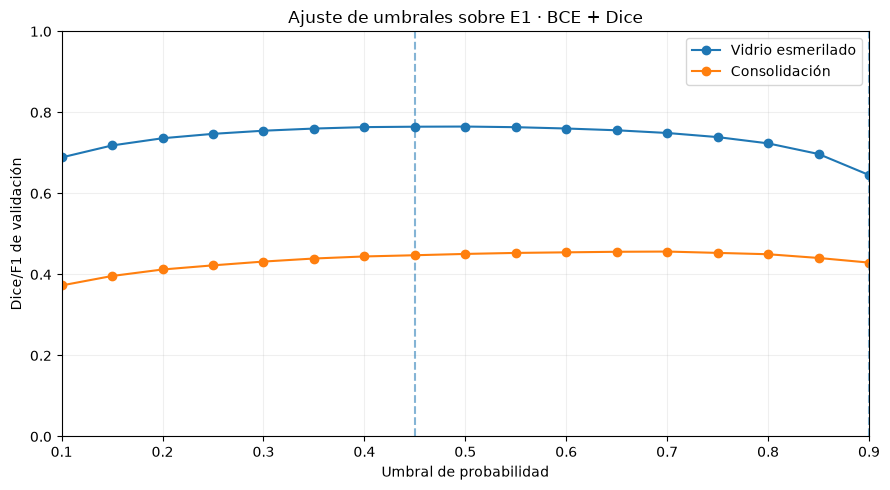

,configuración,Dice_promedio,F1_acumulado_Kaggle
0,Umbral 0.5,0.6078,0.7245
1,Umbrales ajustados,0.5969,0.7348


In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
for channel, class_name in enumerate(CLASS_NAMES[:2]):
    curve = threshold_results[threshold_results["clase"] == class_name]
    ax.plot(
        curve["umbral"],
        curve["Dice_F1"],
        marker="o",
        label=class_name,
    )
    ax.axvline(best_thresholds[channel], linestyle="--", alpha=0.55)

ax.set(
    title=f"Ajuste de umbrales sobre {selected_experiment_name}",
    xlabel="Umbral de probabilidad",
    ylabel="Dice/F1 de validación",
    xlim=(threshold_grid.min(), threshold_grid.max()),
    ylim=(0, 1),
)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

tuned_metrics = evaluate_segmentation(
    y_val_native,
    selected_probabilities_val,
    thresholds=best_thresholds,
)
threshold_comparison = pd.concat(
    [
        selected_fixed_metrics.assign(configuración="Umbral 0.5"),
        tuned_metrics.assign(configuración="Umbrales ajustados"),
    ],
    ignore_index=True,
)
display_metrics(threshold_comparison)

threshold_summary = pd.DataFrame(
    [
        {
            "configuración": "Umbral 0.5",
            "Dice_promedio": mean_target_dice(selected_fixed_metrics),
            "F1_acumulado_Kaggle": pooled_f1(selected_fixed_metrics),
        },
        {
            "configuración": "Umbrales ajustados",
            "Dice_promedio": mean_target_dice(tuned_metrics),
            "F1_acumulado_Kaggle": pooled_f1(tuned_metrics),
        },
    ]
)
threshold_summary.style.format(precision=4)

## Análisis visual de las predicciones

Además de las métricas agregadas observamos las regiones predichas. El color naranja representa vidrio esmerilado y el azul representa consolidación. La comparación permite detectar bordes imprecisos, falsos positivos fuera del pulmón y lesiones pequeñas que el modelo no recupera.

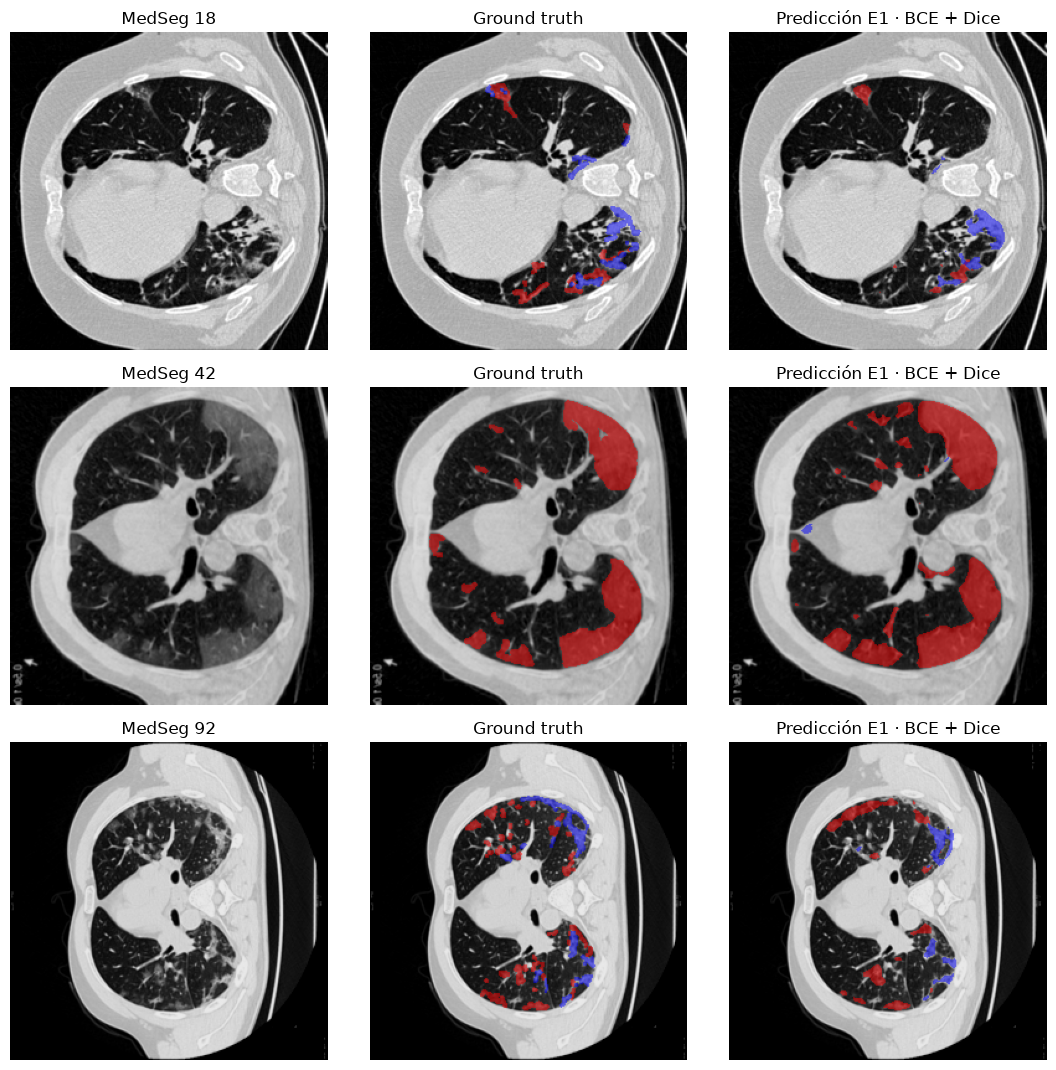

In [32]:
def plot_validation_predictions(
    dataset,
    probabilities,
    original_indices,
    thresholds,
    experiment_name,
    rows=3,
):
    positions = np.linspace(
        0, len(dataset) - 1, min(rows, len(dataset)), dtype=int
    )
    fig, axes = plt.subplots(len(positions), 3, figsize=(11, 3.6 * len(positions)))
    if len(positions) == 1:
        axes = axes[None, :]

    for row, position in enumerate(positions):
        image_tensor, target_tensor = dataset[position]
        image = image_tensor[0].numpy() * train_std + train_mean
        targets = target_tensor.permute(1, 2, 0).numpy().astype(bool)
        predictions = probabilities[position] >= np.asarray(thresholds)

        axes[row, 0].imshow(image, cmap="gray", vmin=-1000, vmax=300)
        axes[row, 0].set_title(f"MedSeg {original_indices[position]}")

        axes[row, 1].imshow(image, cmap="gray", vmin=-1000, vmax=300)
        axes[row, 1].imshow(
            np.ma.masked_where(~targets[..., 0], targets[..., 0]),
            cmap="autumn",
            alpha=0.5,
        )
        axes[row, 1].imshow(
            np.ma.masked_where(~targets[..., 1], targets[..., 1]),
            cmap="winter",
            alpha=0.5,
        )
        axes[row, 1].set_title("Ground truth")

        axes[row, 2].imshow(image, cmap="gray", vmin=-1000, vmax=300)
        axes[row, 2].imshow(
            np.ma.masked_where(~predictions[..., 0], predictions[..., 0]),
            cmap="autumn",
            alpha=0.5,
        )
        axes[row, 2].imshow(
            np.ma.masked_where(~predictions[..., 1], predictions[..., 1]),
            cmap="winter",
            alpha=0.5,
        )
        axes[row, 2].set_title(f"Predicción {experiment_name}")

        for axis in axes[row]:
            axis.axis("off")

    plt.tight_layout()
    plt.show()


plot_validation_predictions(
    validation_dataset,
    selected_probabilities_val_small,
    val_indices_b0,
    best_thresholds,
    selected_experiment_name,
)

## Análisis de errores de consolidación

La consolidación es la clase más difícil. Primero contamos sus aciertos, falsos positivos y falsos negativos para saber si el modelo inventa regiones o deja lesiones sin detectar. Después dividimos los falsos positivos entre los que aparecen fuera del pulmón, los que coinciden con vidrio esmerilado real y los que se encuentran en otra zona pulmonar.

,resultado,píxeles
0,Verdaderos positivos,"5,210"
1,Falsos positivos,"5,892"
2,Falsos negativos,"7,965"


,tipo_de_falso_positivo,píxeles,porcentaje
0,Sobre vidrio esmerilado real,"1,945",33.01%
1,En otra región pulmonar,"2,486",42.19%
2,Fuera del pulmón,"1,461",24.80%


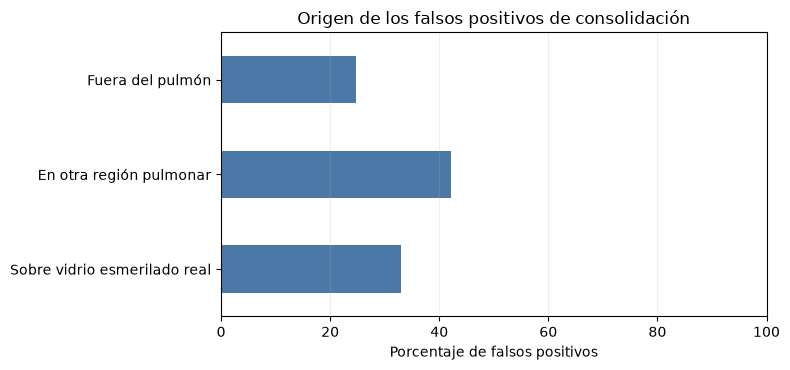

In [33]:
all_validation_masks = np.asarray(
    arrays["masks_medseg"][val_indices_b0], dtype=bool
)
lung_region = all_validation_masks[..., :3].any(axis=-1)
consolidation_truth = y_val_native[..., 1].astype(bool)
consolidation_prediction = (
    selected_probabilities_val[..., 1] >= best_thresholds[1]
)
consolidation_fp = np.logical_and(
    consolidation_prediction, ~consolidation_truth
)
consolidation_tp = np.logical_and(
    consolidation_prediction, consolidation_truth
)
consolidation_fn = np.logical_and(
    ~consolidation_prediction, consolidation_truth
)

consolidation_confusion = pd.DataFrame(
    {
        "resultado": [
            "Verdaderos positivos",
            "Falsos positivos",
            "Falsos negativos",
        ],
        "píxeles": [
            int(consolidation_tp.sum()),
            int(consolidation_fp.sum()),
            int(consolidation_fn.sum()),
        ],
    }
)
display(consolidation_confusion.style.format({"píxeles": "{:,}"}))

fp_on_ground_glass = np.logical_and(
    consolidation_fp, y_val_native[..., 0].astype(bool)
)
fp_outside_lung = np.logical_and(consolidation_fp, ~lung_region)
fp_other_lung = np.logical_and(
    consolidation_fp,
    np.logical_and(lung_region, ~y_val_native[..., 0].astype(bool)),
)

consolidation_error_analysis = pd.DataFrame(
    {
        "tipo_de_falso_positivo": [
            "Sobre vidrio esmerilado real",
            "En otra región pulmonar",
            "Fuera del pulmón",
        ],
        "píxeles": [
            int(fp_on_ground_glass.sum()),
            int(fp_other_lung.sum()),
            int(fp_outside_lung.sum()),
        ],
    }
)
total_consolidation_fp = int(consolidation_fp.sum())
consolidation_error_analysis["porcentaje"] = (
    100
    * consolidation_error_analysis["píxeles"]
    / max(total_consolidation_fp, 1)
)

display(
    consolidation_error_analysis.style.format(
        {"píxeles": "{:,}", "porcentaje": "{:.2f}%"}
    )
)
ax = consolidation_error_analysis.plot.barh(
    x="tipo_de_falso_positivo",
    y="porcentaje",
    legend=False,
    figsize=(8, 3.8),
    color="#4C78A8",
)
ax.set(
    title="Origen de los falsos positivos de consolidación",
    xlabel="Porcentaje de falsos positivos",
    ylabel="",
    xlim=(0, 100),
)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## Inferencia sobre prueba y archivo de entrega

Aplicamos exactamente el mismo preprocesamiento a las diez imágenes de prueba. Las probabilidades se producen a 256 por 256 y después se interpolan a 512 por 512. Los umbrales se aplican al final, ya que redimensionar una máscara binaria podría introducir bordes artificiales.

La competencia no utiliza RLE. El arreglo final debe tener la forma `(10, 512, 512, 2)` y se aplana siguiendo el orden predeterminado de NumPy. La página de evaluación presenta una inconsistencia: el texto menciona `Predicted`, mientras que su ejemplo de código utiliza `Expected`. Por eso generamos una versión para cada encabezado sin cambiar las predicciones. El archivo principal conserva `Expected`, igual que el ejemplo oficial; si Kaggle solicita el otro nombre se utiliza la segunda versión.

In [34]:
def prepare_test_tensor(image_array, mean, std, target_size=256):
    tensors = []
    for index in range(len(image_array)):
        image = np.asarray(image_array[index], dtype=np.float32).copy()
        image = np.clip(image, -1500.0, 500.0)
        image = (image - mean) / std
        tensor = torch.from_numpy(image).permute(2, 0, 1)
        tensor = F.interpolate(
            tensor.unsqueeze(0),
            size=(target_size, target_size),
            mode="bilinear",
            align_corners=False,
            antialias=True,
        ).squeeze(0)
        tensors.append(tensor.float())
    return torch.stack(tensors)


x_test = prepare_test_tensor(
    arrays["test_images_medseg"], train_mean, train_std, TARGET_SIZE
)
test_loader = DataLoader(
    TensorDataset(x_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_probabilities_small = predict_probabilities(
    selected_model, test_loader
)

test_probabilities = resize_probabilities(
    test_probabilities_small, output_size=512
)

threshold_array = np.asarray(best_thresholds, dtype=np.float32).reshape(
    1, 1, 1, 2
)
test_masks_prediction = (
    test_probabilities >= threshold_array
).astype(np.uint8)

assert test_masks_prediction.shape == (10, 512, 512, 2)
assert set(np.unique(test_masks_prediction)).issubset({0, 1})

print("Modelo final:", selected_experiment_name)
print("Umbrales:", dict(zip(CLASS_NAMES[:2], best_thresholds)))
print("Forma final:", test_masks_prediction.shape)

Modelo final: E1 · BCE + Dice
Umbrales: {'Vidrio esmerilado': 0.45, 'Consolidación': 0.9}
Forma final: (10, 512, 512, 2)


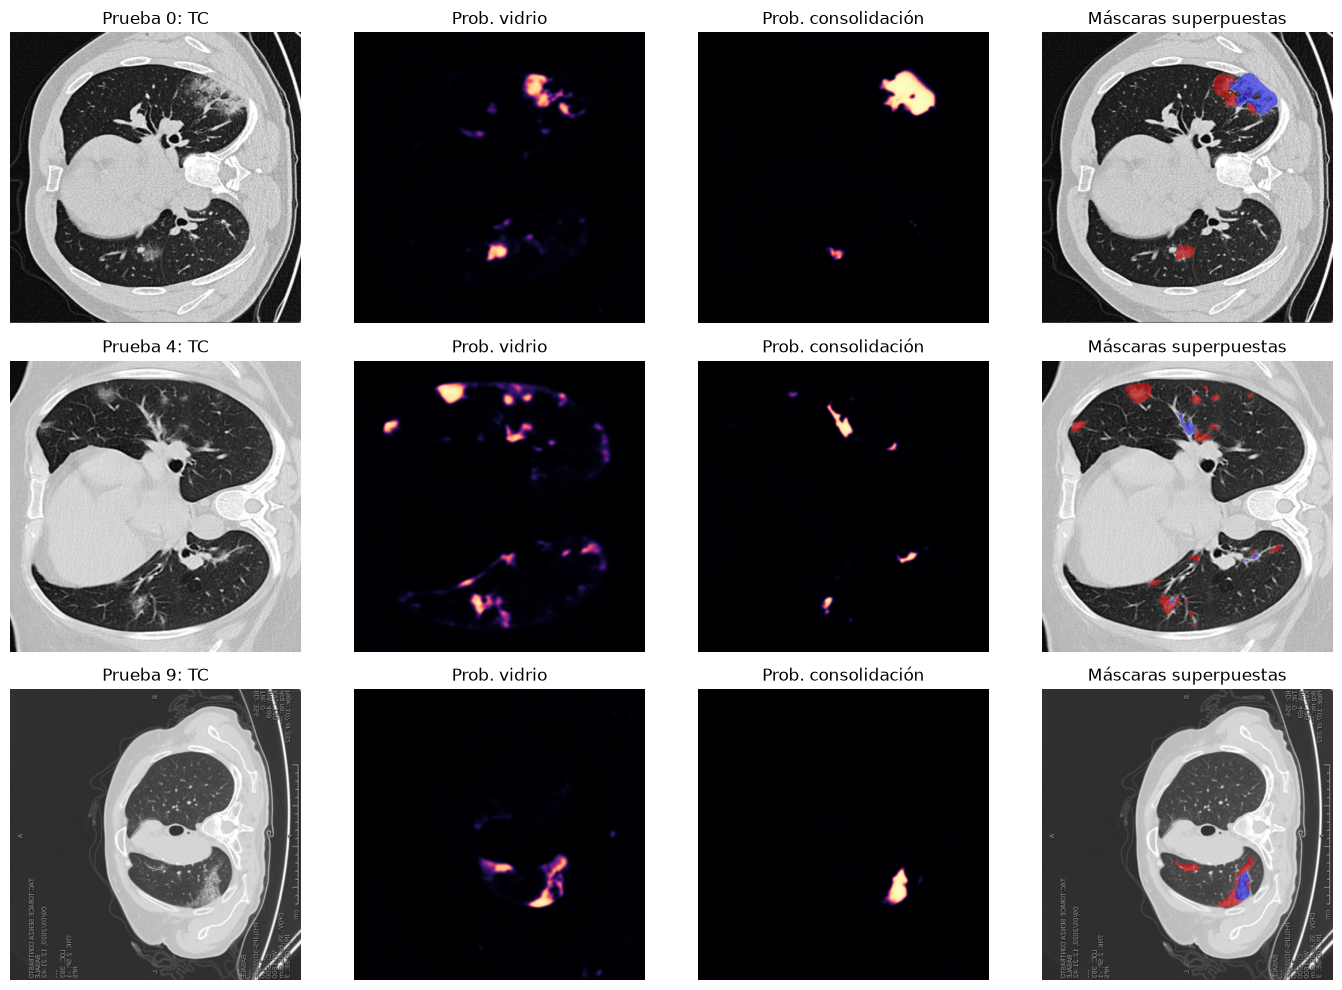

In [35]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row, test_index in enumerate([0, 4, 9]):
    original = np.asarray(
        arrays["test_images_medseg"][test_index, ..., 0],
        dtype=np.float32,
    )
    display_image = np.clip(original, -1500, 500)

    axes[row, 0].imshow(display_image, cmap="gray")
    axes[row, 0].set_title(f"Prueba {test_index}: TC")
    axes[row, 1].imshow(
        test_probabilities[test_index, ..., 0],
        cmap="magma",
        vmin=0,
        vmax=1,
    )
    axes[row, 1].set_title("Prob. vidrio")
    axes[row, 2].imshow(
        test_probabilities[test_index, ..., 1],
        cmap="magma",
        vmin=0,
        vmax=1,
    )
    axes[row, 2].set_title("Prob. consolidación")
    axes[row, 3].imshow(display_image, cmap="gray")
    axes[row, 3].imshow(
        np.ma.masked_where(
            test_masks_prediction[test_index, ..., 0] == 0,
            test_masks_prediction[test_index, ..., 0],
        ),
        cmap="autumn",
        alpha=0.5,
    )
    axes[row, 3].imshow(
        np.ma.masked_where(
            test_masks_prediction[test_index, ..., 1] == 0,
            test_masks_prediction[test_index, ..., 1],
        ),
        cmap="winter",
        alpha=0.5,
    )
    axes[row, 3].set_title("Máscaras superpuestas")

    for axis in axes[row]:
        axis.axis("off")

plt.tight_layout()
plt.show()

In [36]:
flattened_prediction = test_masks_prediction.ravel(order="C")
expected_rows = 10 * 512 * 512 * 2
submission_expected = pd.DataFrame(
    {
        "Id": np.arange(expected_rows, dtype=np.int64),
        "Expected": flattened_prediction.astype(np.uint8),
    }
)
submission_predicted = submission_expected.rename(
    columns={"Expected": "Predicted"}
)

assert len(submission_expected) == expected_rows
assert submission_expected.columns.tolist() == ["Id", "Expected"]
assert submission_predicted.columns.tolist() == ["Id", "Predicted"]
assert submission_expected["Id"].iloc[0] == 0
assert submission_expected["Id"].iloc[-1] == expected_rows - 1
assert set(submission_expected["Expected"].unique()).issubset({0, 1})

submission_path = ARTIFACT_DIR / "submission.csv"
alternate_submission_path = (
    ARTIFACT_DIR / "submission_predicted_header.csv"
)
submission_expected.to_csv(submission_path, index=False)
submission_predicted.to_csv(alternate_submission_path, index=False)

print(f"Archivo creado: {submission_path}")
print(f"Alternativa creada: {alternate_submission_path}")
print(f"Filas: {len(submission_expected):,}")
print(f"Tamaño: {submission_path.stat().st_size / 1024**2:.1f} MiB")
submission_expected.head()

Archivo creado: artifacts/submission.csv
Alternativa creada: artifacts/submission_predicted_header.csv
Filas: 5,242,880
Tamaño: 48.9 MiB


,Id,Expected
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


## Conclusión

La siguiente celda construye la conclusión con los resultados reales de la ejecución. Así evitamos incluir cifras antes del entrenamiento y conservamos una narración reproducible para la entrega final.

In [37]:
from IPython.display import Markdown, display

fixed_score = mean_target_dice(selected_fixed_metrics)
tuned_score = mean_target_dice(tuned_metrics)
fixed_pooled_score = pooled_f1(selected_fixed_metrics)
tuned_pooled_score = pooled_f1(tuned_metrics)
threshold_delta = tuned_pooled_score - fixed_pooled_score
threshold_effect = (
    "mejoró"
    if threshold_delta > 0
    else "se mantuvo"
    if np.isclose(threshold_delta, 0)
    else "disminuyó"
)
dominant_error = consolidation_error_analysis.sort_values(
    "píxeles", ascending=False
).iloc[0]
selected_consolidation_row = tuned_metrics.loc[
    tuned_metrics["clase"] == "Consolidación"
].iloc[0]
balanced_metrics = experiment_candidates[
    balanced_experiment_name
]["native_metrics"]
balanced_macro_score = mean_target_dice(balanced_metrics)
e2_native_score = experiment_candidates[
    f"E2 · Fuentes balanceadas · {selected_loss_name_e2}"
]["pooled_f1"]
e3_native_score = experiment_candidates[
    f"E3 · Balanceado + reflejo · {selected_loss_name_e2}"
]["pooled_f1"]
augmentation_effect = e3_native_score - e2_native_score

conclusion_text = f'''
El modelo seleccionado para la entrega según el F1 acumulado de Kaggle fue **{selected_experiment_name}**. A la resolución original de 512 por 512 obtuvo un Dice promedio por clase de **{fixed_score:.4f}** y un F1 acumulado de **{fixed_pooled_score:.4f}**. Al usar umbrales de **{best_thresholds[0]:.2f}** para vidrio esmerilado y **{best_thresholds[1]:.2f}** para consolidación, el F1 acumulado {threshold_effect} a **{tuned_pooled_score:.4f}**, una diferencia de **{threshold_delta:+.4f}**. El Dice promedio ajustado fue **{tuned_score:.4f}**.

Sin embargo, **{balanced_experiment_name}** obtuvo el mejor equilibrio cuando ambas clases recibieron el mismo peso, con un Dice promedio de **{balanced_macro_score:.4f}**. Esta diferencia ocurre porque hay muchos más píxeles de vidrio esmerilado que de consolidación. El F1 acumulado favorece al modelo que resuelve mejor la clase grande, aunque su desempeño en la clase pequeña sea inferior. Por eso reportamos las dos perspectivas en lugar de describir un único número como toda la calidad del modelo.

La principal fortaleza de la solución es que cada cambio se comparó sobre la misma partición y con **{MAX_OPTIMIZER_STEPS} actualizaciones máximas**. Primero establecimos una U-Net reproducible con PyTorch, después estudiamos una pérdida sensible al desbalance, incorporamos Radiopaedia mediante lotes balanceados y finalmente probamos un reflejo horizontal moderado. Frente a E2, el aumento cambió el F1 acumulado en **{augmentation_effect:+.4f}**. El mapeo de memoria evitó cargar simultáneamente los archivos completos y la precisión mixta redujo el costo del entrenamiento cuando hubo GPU.

El modelo elegido por la métrica oficial alcanzó una sensibilidad de **{selected_consolidation_row['sensibilidad']:.4f}** en consolidación, por lo que su principal debilidad es dejar parte de esta clase sin detectar. Entre sus falsos positivos, la categoría más frecuente fue **{dominant_error['tipo_de_falso_positivo']}**, con **{dominant_error['porcentaje']:.2f} %**. Esto orienta mejor el trabajo futuro que asumir que todos los errores se encuentran fuera del pulmón.

La mayor limitación es el tamaño de la validación. Diez cortes no representan toda la variabilidad clínica y no contamos con identificadores completos de paciente para asegurar independencia entre imágenes. También existe un cambio de dominio entre MedSeg y Radiopaedia, mientras que el modelo bidimensional no aprovecha la continuidad entre cortes vecinos. El resultado debe interpretarse como evidencia experimental del reto y no como desempeño clínico.

Como trabajo futuro proponemos una validación agrupada por paciente cuando existan metadatos, aumentos de datos moderados, restricción de las predicciones al pulmón y comparación con encoders residuales. También sería conveniente repetir el entrenamiento con varias semillas para distinguir una mejora consistente de la variación producida por una sola partición.
'''
display(Markdown(conclusion_text))


El modelo seleccionado para la entrega según el F1 acumulado de Kaggle fue **E1 · BCE + Dice**. A la resolución original de 512 por 512 obtuvo un Dice promedio por clase de **0.6078** y un F1 acumulado de **0.7245**. Al usar umbrales de **0.45** para vidrio esmerilado y **0.90** para consolidación, el F1 acumulado mejoró a **0.7348**, una diferencia de **+0.0103**. El Dice promedio ajustado fue **0.5969**.

Sin embargo, **E1 · BCE + Dice** obtuvo el mejor equilibrio cuando ambas clases recibieron el mismo peso, con un Dice promedio de **0.6078**. Esta diferencia ocurre porque hay muchos más píxeles de vidrio esmerilado que de consolidación. El F1 acumulado favorece al modelo que resuelve mejor la clase grande, aunque su desempeño en la clase pequeña sea inferior. Por eso reportamos las dos perspectivas en lugar de describir un único número como toda la calidad del modelo.

La principal fortaleza de la solución es que cada cambio se comparó sobre la misma partición y con **575 actualizaciones máximas**. Primero establecimos una U-Net reproducible con PyTorch, después estudiamos una pérdida sensible al desbalance, incorporamos Radiopaedia mediante lotes balanceados y finalmente probamos un reflejo horizontal moderado. Frente a E2, el aumento cambió el F1 acumulado en **-0.0171**. El mapeo de memoria evitó cargar simultáneamente los archivos completos y la precisión mixta redujo el costo del entrenamiento cuando hubo GPU.

El modelo elegido por la métrica oficial alcanzó una sensibilidad de **0.3954** en consolidación, por lo que su principal debilidad es dejar parte de esta clase sin detectar. Entre sus falsos positivos, la categoría más frecuente fue **En otra región pulmonar**, con **42.19 %**. Esto orienta mejor el trabajo futuro que asumir que todos los errores se encuentran fuera del pulmón.

La mayor limitación es el tamaño de la validación. Diez cortes no representan toda la variabilidad clínica y no contamos con identificadores completos de paciente para asegurar independencia entre imágenes. También existe un cambio de dominio entre MedSeg y Radiopaedia, mientras que el modelo bidimensional no aprovecha la continuidad entre cortes vecinos. El resultado debe interpretarse como evidencia experimental del reto y no como desempeño clínico.

Como trabajo futuro proponemos una validación agrupada por paciente cuando existan metadatos, aumentos de datos moderados, restricción de las predicciones al pulmón y comparación con encoders residuales. También sería conveniente repetir el entrenamiento con varias semillas para distinguir una mejora consistente de la variación producida por una sola partición.


## Referencias

Kaggle. *COVID-19 CT Images Segmentation*. https://www.kaggle.com/competitions/covid-segmentation

vimpsykal. *unet_segmentation*. https://www.kaggle.com/code/vimpsykal/unet-segmentation

Ronneberger, O., Fischer, P. y Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. Medical Image Computing and Computer-Assisted Intervention. https://arxiv.org/abs/1505.04597

Milletari, F., Navab, N. y Ahmadi, S. A. (2016). *V-Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation*. 3DV. https://arxiv.org/abs/1606.04797

Paszke, A. et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library*. Advances in Neural Information Processing Systems, 32. https://arxiv.org/abs/1912.01703

Bankier, A. A. et al. (2024). *Fleischner Society: Glossary of Terms for Thoracic Imaging*. Radiology, 310(2). https://doi.org/10.1148/radiol.232558